## Bayesian Additive Regression Trees (BART) for  Ocean Color Remote Sensing

<img src="./manuscript/figures/eat_my_priors2.png" height="400" alt="BARTimg" style="float: left; margin-right: 30px;">

In this notebook, we build and evaluate a multivariate BART model to predict the logarithm of phytoplankton absorption (aph) at multiple wavelengths using top-of-atmosphere (TOA) radiance measurements. The dataset consists of spectrally-resolved radiance features that have been Fresnel- and Rayleigh-corrected, but not fully atmosphere-corrected, capturing realistic levels of noise and uncertainty in satellite remote sensing.

I leverage the flexibility of BART to accommodate the high multicollinearity among spectral bands without requiring strict assumptions about linearity or parametric form. The model is implemented in PyMC using the pymc-bart extension, allowing for a fully Bayesian treatment of uncertainty and posterior inference.

Key goals of this notebook include:
* Structuring the input data and response variables for multivariate modeling
* Fitting a BART model with a matrix-valued response
* Visualizing posterior draws and posterior predictive distributions
* Diagnosing model behavior
* Laying the groundwork for comparison with alternative models 

This notebook is part of a broader effort to advocate for Bayesian methods in the ocean color community and is ultimately destined for inclusion in a reproducible manuscript. Feedback and discussion are welcome.

Need help with your project? Hit me up: erdemk@pm.me 

In [1]:
from pathlib import Path

import pymc as pm
import pymc_bart as pmb

import pandas as pd
import numpy as np
import matplotlib.pyplot as pp
from matplotlib.lines import Line2D
import arviz as az
import seaborn as sb

In [2]:
print('Package Versions: ', end='\n' + 50*'--' + '\n')
print(f'PyMC - {pm.__version__}')
print(f'PyMC-BART - {pmb.__version__}')
print(f'PanDaS - {pd.__version__}')
print(f'Arviz - {az.__version__}')
print(f'Seaborn - {sb.__version__}')

Package Versions: 
----------------------------------------------------------------------------------------------------
PyMC - 5.20.1
PyMC-BART - 0.9.0
PanDaS - 2.2.3
Arviz - 0.21.0
Seaborn - 0.13.2


In [3]:
pp.style.use('arviz-darkgrid')

#### Phytoplankton Absorption Prediction


In [4]:
data_dir = Path.cwd() / 'data' / '03_transformed'
data_dir.exists()

True

In [5]:
df_log = pd.read_parquet(data_dir / 'df_log.pqt')

In [420]:
df_log.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496 entries, 0 to 495
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   log_Rrc_412  494 non-null    float64
 1   log_Rrc_443  494 non-null    float64
 2   log_Rrc_490  494 non-null    float64
 3   log_Rrc_510  494 non-null    float64
 4   log_Rrc_555  494 non-null    float64
 5   log_Rrc_670  494 non-null    float64
 6   log_aph443   168 non-null    float64
 7   log_aph555   165 non-null    float64
 8   log_aph670   168 non-null    float64
 9   log_chl      425 non-null    float64
 10  hplc_flag    496 non-null    int8   
dtypes: float64(10), int8(1)
memory usage: 39.4 KB


In [6]:
aph_subset = df_log.filter(regex='Rrc|aph')

In [421]:
chl_subset = df_log.filter(regex='Rrc|chl|hplc')

In [422]:
chl_subset.head()

,log_Rrc_412,log_Rrc_443,log_Rrc_490,log_Rrc_510,log_Rrc_555,log_Rrc_670,log_chl,hplc_flag
0,-1.917660,-1.905994,-1.930380,-1.975543,-2.040501,-2.176858,-1.040959,0
1,-1.977774,-1.973214,-2.017116,-2.101675,-2.205903,-2.319302,-0.928118,2
2,-2.352334,-2.357865,-2.372588,-2.433492,-2.577377,-2.929113,NaN,-1
3,-2.231428,-2.231674,-2.256908,-2.333192,-2.478052,-2.757732,-0.211832,2
4,-2.023925,-2.047304,-2.112433,-2.223764,-2.380771,-2.599169,-0.801343,1


In [7]:
aph_subset.head()

,log_Rrc_412,log_Rrc_443,log_Rrc_490,log_Rrc_510,log_Rrc_555,log_Rrc_670,log_aph443,log_aph555,log_aph670
0,-1.917660,-1.905994,-1.930380,-1.975543,-2.040501,-2.176858,NaN,NaN,NaN
1,-1.977774,-1.973214,-2.017116,-2.101675,-2.205903,-2.319302,NaN,NaN,NaN
2,-2.352334,-2.357865,-2.372588,-2.433492,-2.577377,-2.929113,-1.511731,-2.414539,-1.982967
3,-2.231428,-2.231674,-2.256908,-2.333192,-2.478052,-2.757732,-1.641494,-2.508638,-2.029188
4,-2.023925,-2.047304,-2.112433,-2.223764,-2.380771,-2.599169,NaN,NaN,NaN


In [416]:
aph_subset.to_csv(data_dir /'aph_subset.csv')

In [8]:
image_save_path = Path.cwd() / 'manuscript' /'figures'
assert image_save_path.exists()

/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


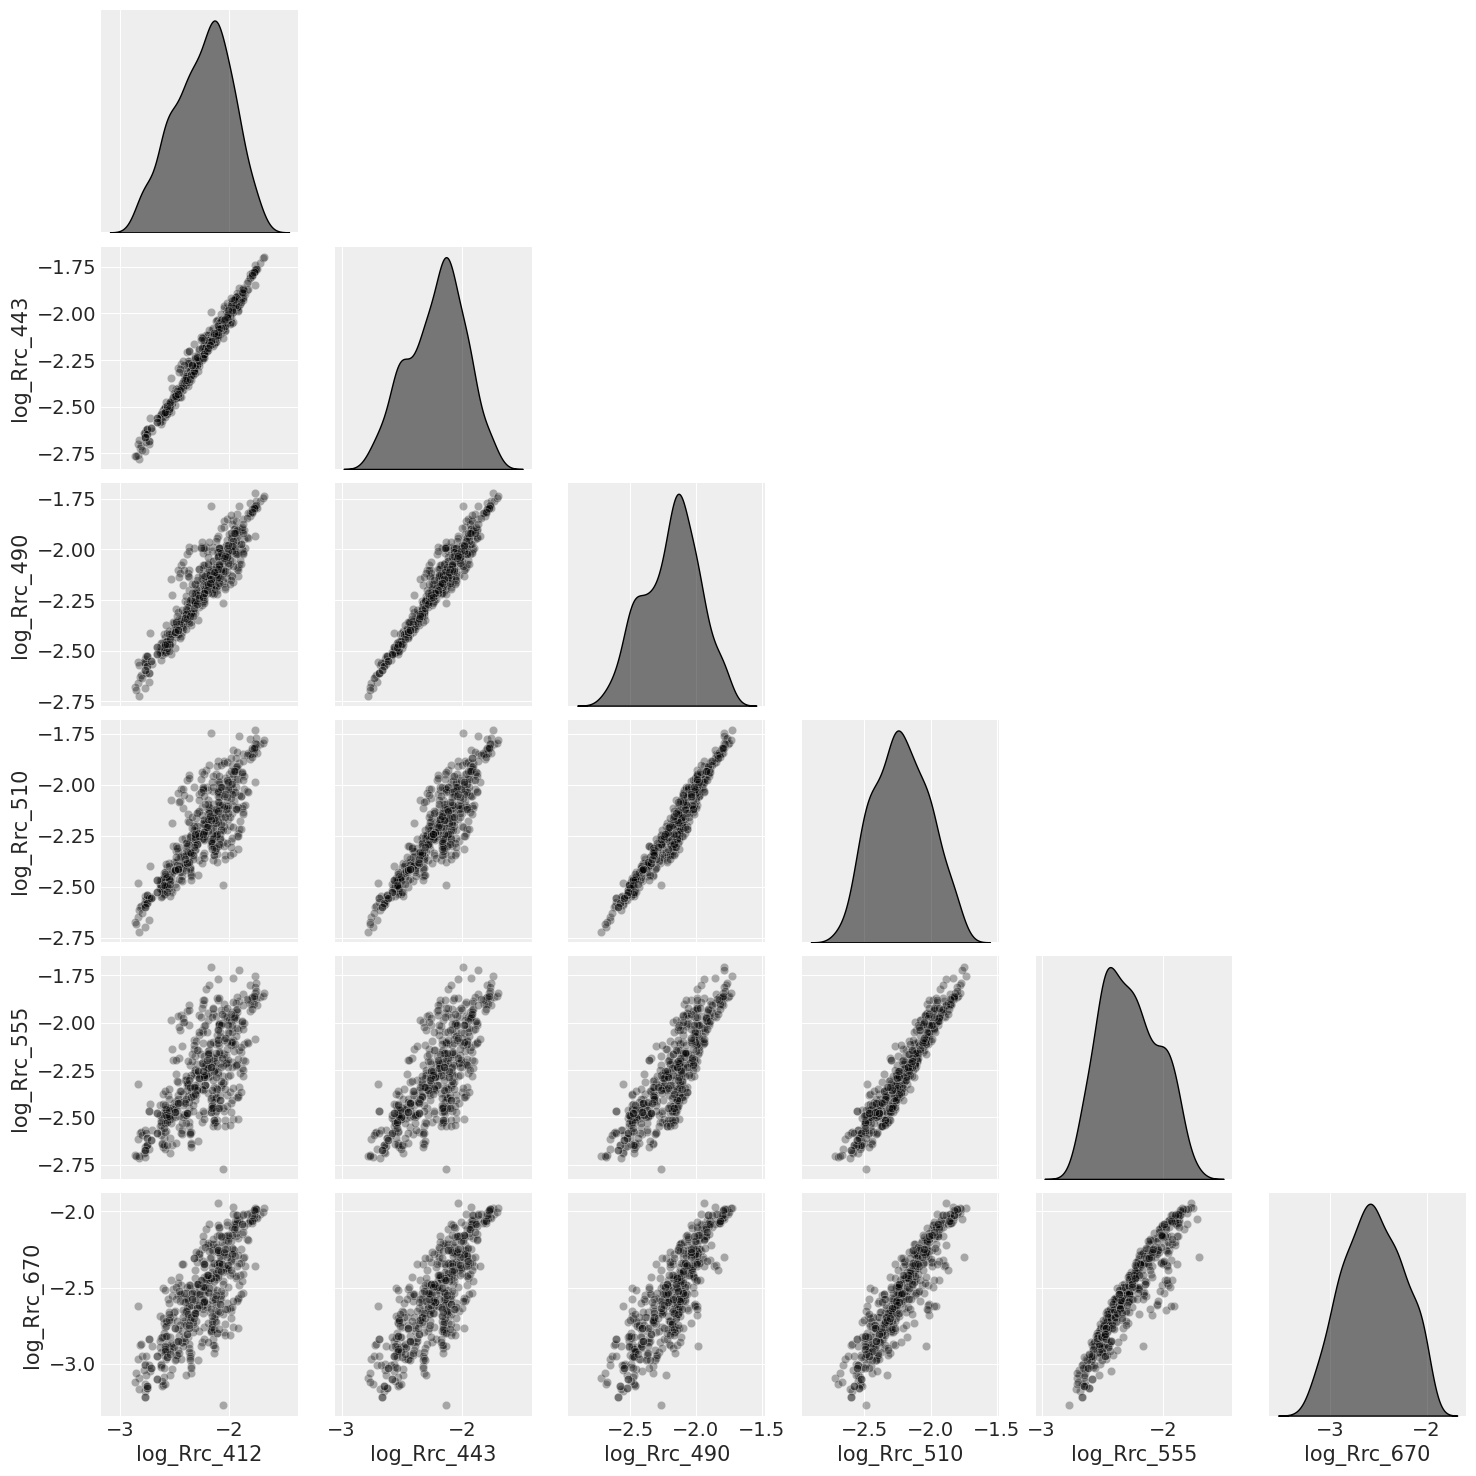

In [418]:
sb.pairplot(aph_subset.filter(
    like='Rrc', axis=1), corner=True, plot_kws = {'color': 'k', 'alpha': 0.3}, 
    diag_kws={'color': 'k', 'alpha': 0.5}, diag_kind='kde')
f = pp.gcf()

In [419]:

f.savefig(image_save_path / 'log_rrc_pairplot_kde_diag.pdf', dpi=300)

/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


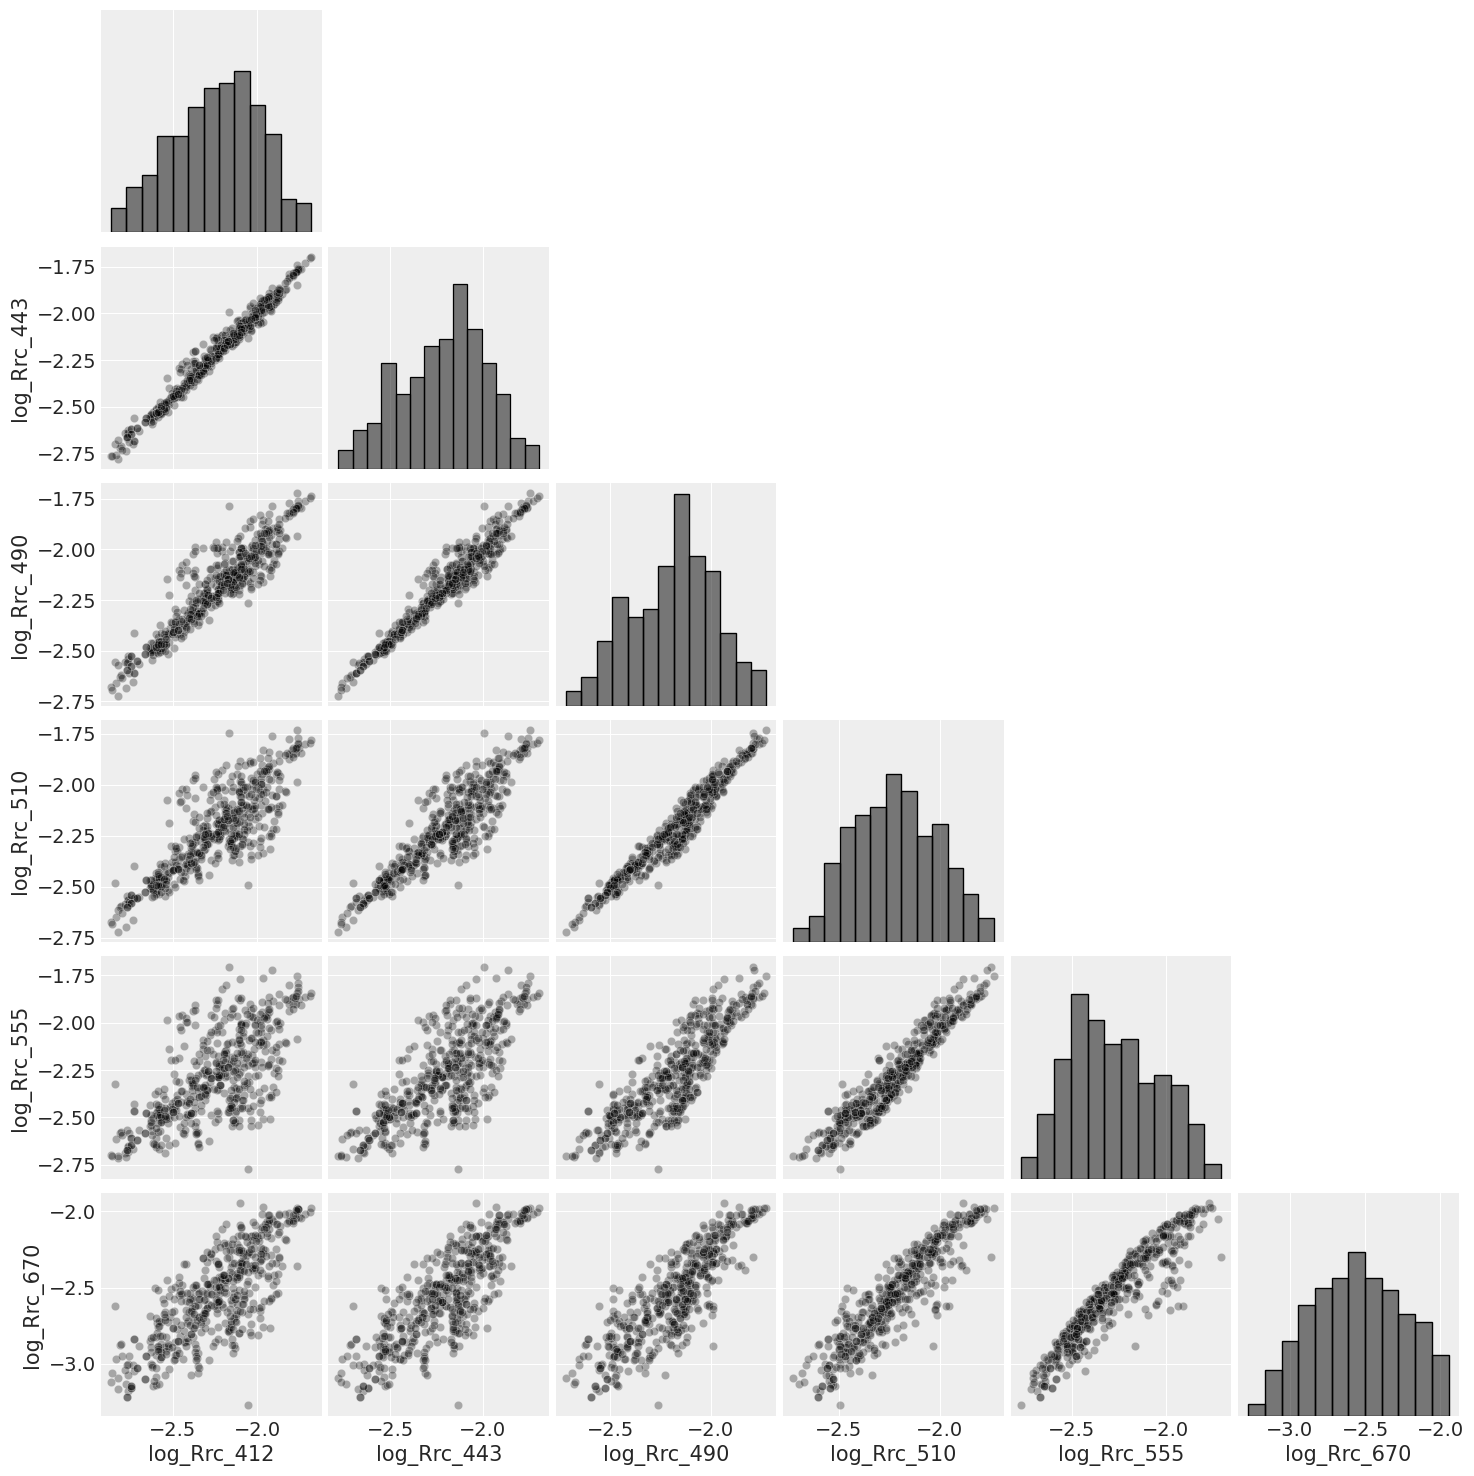

In [9]:
sb.pairplot(aph_subset.filter(
    like='Rrc', axis=1), corner=True, plot_kws = {'color': 'k', 'alpha': 0.3}, 
    diag_kws={'color': 'k', 'alpha': 0.5})
f = pp.gcf()
f.savefig(image_save_path / 'log_rrc_pairplot.png', dpi=300)
f.savefig(image_save_path / 'log_rrc_pairplot.pdf', dpi=300)

In [10]:
aph_subset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496 entries, 0 to 495
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   log_Rrc_412  494 non-null    float64
 1   log_Rrc_443  494 non-null    float64
 2   log_Rrc_490  494 non-null    float64
 3   log_Rrc_510  494 non-null    float64
 4   log_Rrc_555  494 non-null    float64
 5   log_Rrc_670  494 non-null    float64
 6   log_aph443   168 non-null    float64
 7   log_aph555   165 non-null    float64
 8   log_aph670   168 non-null    float64
dtypes: float64(9)
memory usage: 35.0 KB


In [ ]:
X = aph_subset.dropna().filter(regex='Rrc')
Y = aph_subset.dropna().filter(regex='aph')

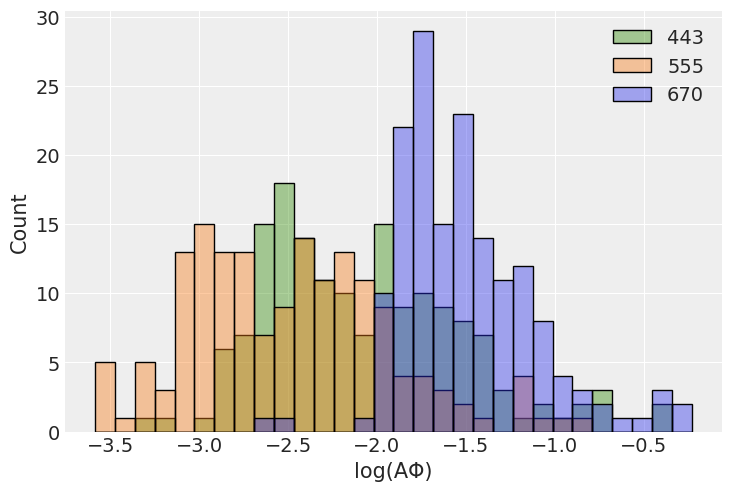

In [ ]:
ax = sb.histplot(
    aph_subset.dropna().filter(regex='aph'), fill=True, alpha=0.4, legend=False, bins=30)
ax.legend(['443', '555', '670'])
ax.set_xlabel('log(AΦ)')
f = pp.gcf()
#f.savefig(image_save_path / 'aph_dist.png', dpi=300)
#f.savefig(image_save_path / 'aph_dist.pdf', dpi=300)

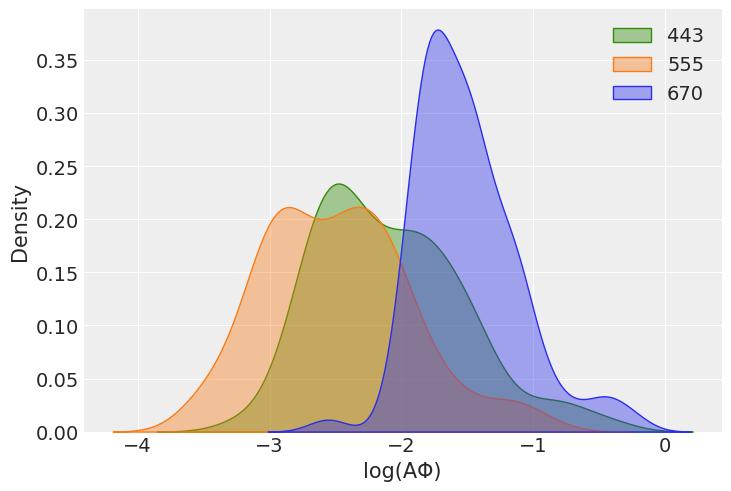

In [13]:
ax = sb.kdeplot(aph_subset.dropna().filter(regex='aph'), fill=True, alpha=0.4, legend=False)
ax.legend(['443', '555', '670'])
ax.set_xlabel('log(AΦ)')
f = pp.gcf()
f.savefig(image_save_path / 'aph_dist.png', dpi=300)
f.savefig(image_save_path / 'aph_dist.pdf', dpi=300)

## Modeling

### Modeling Preparation

In [14]:
x_idx, x_names = X.columns.factorize()
y_idx, y_names = Y.columns.factorize()
λ =   [li.split('Rrc_')[-1] for li in x_names]
λ_aph =   [li.split('aph')[-1] for li in y_names]
coords= {
    'obs_idx': X.index,
    'λ_toa': λ, 
    'λ_aφ' : λ_aph
}

### Aφ Model 1 - BART

This is a first stab at predicting Phytoplankton absorption at all 3 wavelengths

In [31]:
with pm.Model(coords=coords) as m_aph:
    X_data = pm.Data('log_Rrc', X, dims=['obs_idx', 'λ_toa'])
    Y_data = pm.Data('log_aφ', Y, dims=['obs_idx', 'λ_aφ'])
    σ = pm.HalfNormal('σ', 0.5, dims='λ_aφ')
    μ = pmb.BART('μ', X=X_data, Y=Y_data, m=10, alpha=0.9, beta=4, dims=('λ_aφ', 'obs_idx')).T
    pm.Normal('likelihood', mu=μ, sigma=σ, observed=Y_data, dims=['obs_idx', 'λ_aφ'])

In [32]:
g = m_aph.to_graphviz()

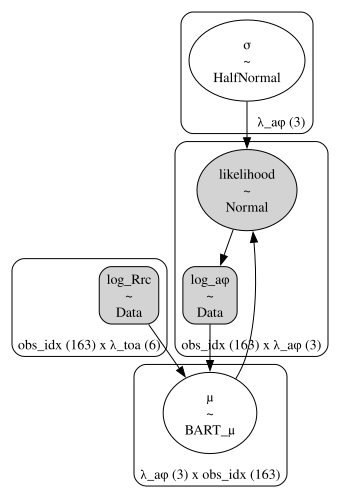

In [33]:
g

Note the arrow from the observed variable $log\_aφ$ to the BART mean (μ) in the model graph. This isn’t part of the generative model.This arrow reflects instead how PyMC builds the computational graph for inference. Internally, the observed data is used to compute residuals and update the trees during sampling, so PyMC shows a dependency that supports posterior updates but doesn’t imply that the BART prior is conditioned on the observed outcome.

In [34]:
with m_aph:
    idata_aph = pm.sample_prior_predictive()

Sampling: [likelihood, μ, σ]


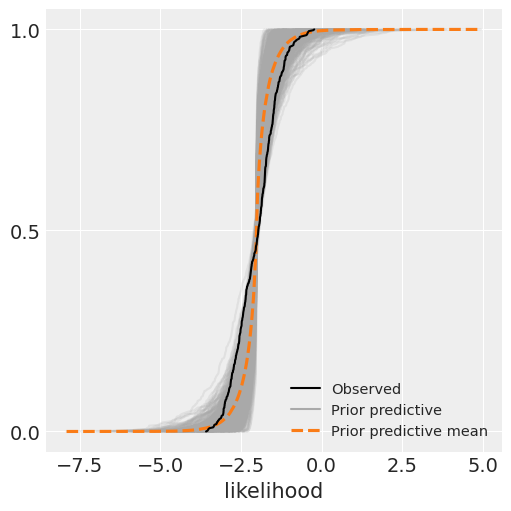

In [35]:
f, ax = pp.subplots(figsize=(5, 5))
ax= az.plot_ppc(idata_aph, group='prior', observed=True, kind='cumulative', ax=ax, colors=['darkgray', 'k', 'C1'])

Priors appear reasonable on account of the simulated output.

In [36]:
with m_aph:
    idata_aph.extend(pm.sample(draws=2000, chains=4, target_accept=0.95))

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [σ]
>PGBART: [μ]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 8 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


#### Sampling diagnostics

There are some warnings about convergence between independent sampling runs. If these are minors, the model is still likely to be OK. The main thing is to make sure that not too many values are beyond a Gelman-Rubin statistic ($\hat{R}$) of 1.01, particularly that we don't get any warnings about Effective Sample Size (ESS).

In [37]:
az.summary(idata_aph).r_hat.value_counts(normalize=True).round(2)

r_hat
1.01    0.66
1.00    0.24
1.02    0.10
1.03    0.01
Name: proportion, dtype: float64

Text(0.5, 0, '$\\hat{R}$')

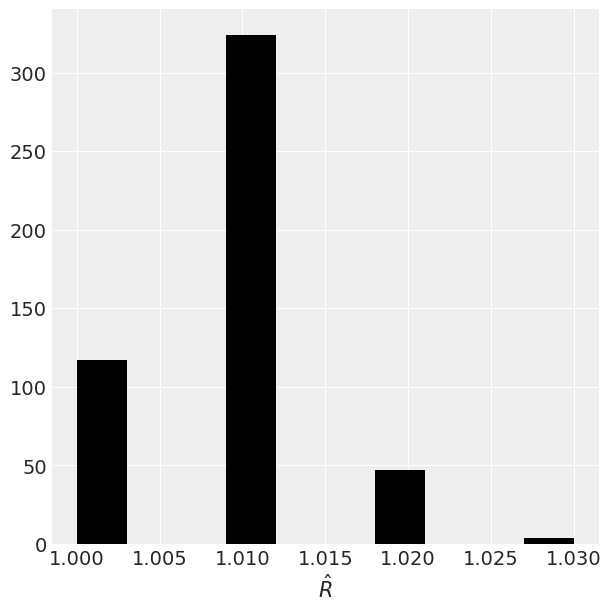

In [38]:
f, ax = pp.subplots(figsize=(6, 6))
az.summary(idata_aph, kind='diagnostics').r_hat.hist(ax=ax, color='k')
ax.set_xlabel(r'$\hat{R}$')

More than 95% of the samples are under 1.01, and the remainder is 1.02 or 1.03 anyway. This is acceptable. Next is to assess ESS, for both posterior region corresponding to  bulk and tail.

Text(0.5, 0, '$ESS_{tail}$')

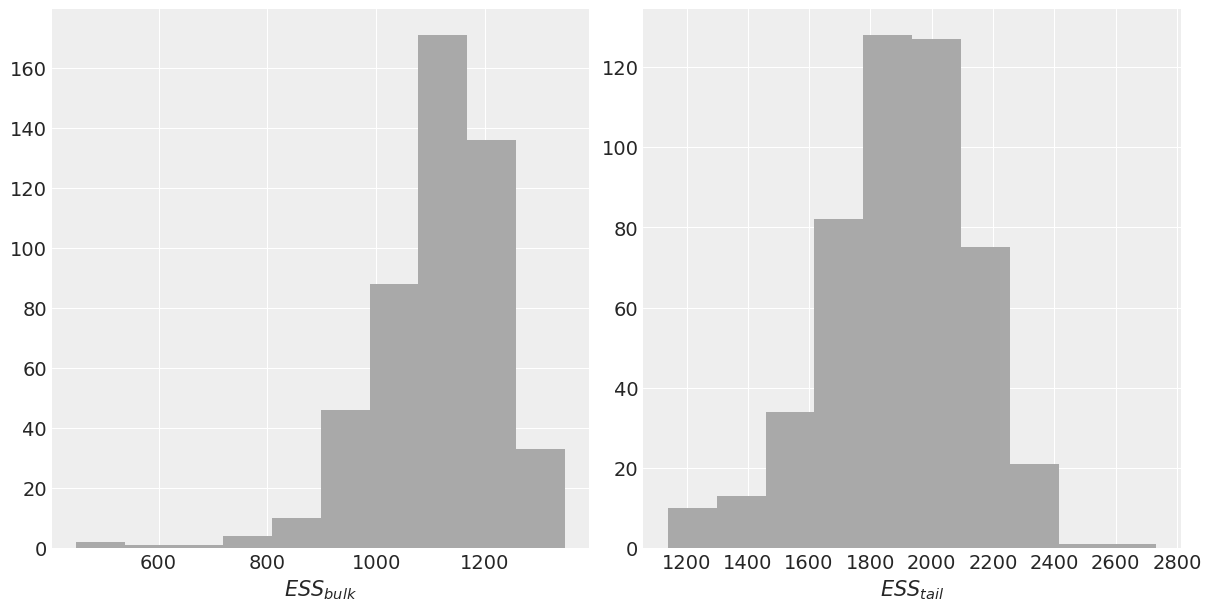

In [39]:
f, axs = pp.subplots(ncols=2, figsize=(12, 6))
az.summary(idata_aph, kind='diagnostics').ess_bulk.hist(ax=axs[0], color='darkgray')
az.summary(idata_aph, kind='diagnostics').ess_tail.hist(ax=axs[1], color='darkgray')
axs[0].set_xlabel(r'$ESS_{bulk}$')
axs[1].set_xlabel(r'$ESS_{tail}$')

Most of bulk and tail ESS are in the thousands of samples. This suggest good sampling.

Another diagnostic is the Energy plot. This applies to Hamiltonian Monte Carlo (HMC) samplers like the No U-Turn Sampler (NUTS), responsible for sampling continuous regions of the posteriorin, which in this case applies to the variance of the likelihood. Indeed the BART component is not continuous. Thus the mean of the likelihood (μ) is determined by the BART posterior, which is sampled using PG-BART (Particle Gibbs for BART). PG-BART is not a gradient-based method — it does not involve leapfrog integration, energy functions, or momentum resampling. Instead, PG-BART operates on discrete tree structures, which are non-differentiable. In particular PG-BART:
* Uses particle filtering + Gibbs sampling to explore the space of trees.
* Resamples trees based on their fit to the data, without needing any gradients.


The Energy plot for HMC helps assess how efficiently the sampler is exploring the posterior distribution. This plot helps assess how efficiently the sampler is exploring the posterior distribution. It shows two key distributions:

* Marginal Energy: The distribution of the Hamiltonian energy values across all samples. This is essentially a measure of the total "energy" (potential + kinetic) of the system at each sample.
* Energy Transition: The distribution of differences in energy between successive samples (i.e., energy jumps). Ideally, the transitions should be smooth and not show large jumps.

These matter because efficient HMC sampling assumes the energy landscape is smooth and traversable. Large or erratic energy transitions may indicate problems such as:

* Poor geometry (e.g., highly curved posteriors)
* Bad parameter scaling or priors
* Sampling stuck in narrow funnels or high-curvature areas


$⇒$ What BFMI Means:

BFMI = Bayesian Fraction of Missing Information

It quantifies how well the momentum resampling step in HMC is helping explore the energy landscape:
$$BFMI=\frac{Var(marginal energy)}{Var(energy transition)}$$
​

A low BFMI means the sampler isn't drawing enough momentum to explore distant parts of the posterior, which can result in biased samples or poor mixing.

$⇒$ What is a Good BFMI Value?

* BFMI ≥ 0.3 is generally considered acceptable.
* BFMI < 0.2 is a red flag indicating poor exploration and possible divergences.
* Ideally, values closer to 1 are better — indicating momentum is appropriately scaled to traverse the typical set efficiently.

$⇒$ How to Use the Plot:

* Compare the marginal energy and energy transition distributions. If they differ sharply, or if BFMI is low, your sampler may be inefficient.
* In ArviZ, low BFMI is often reported with a warning. There may also be differences in the plot (e.g., the energy transition distribution is narrow relative to the marginal energy).

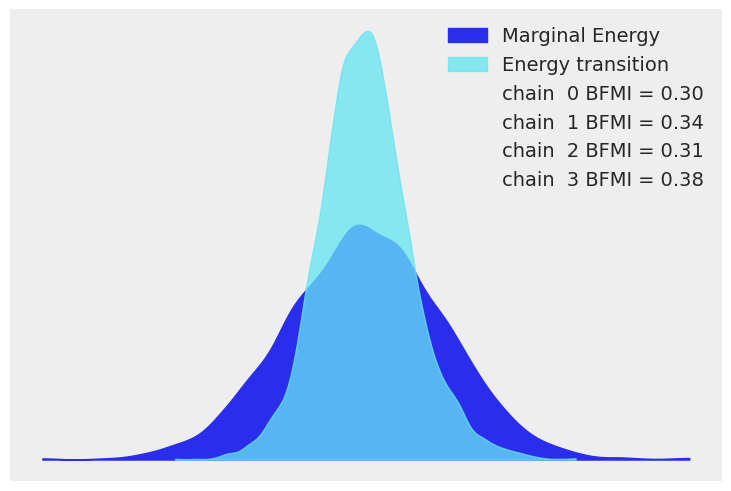

In [40]:
az.plot_energy(idata_aph)
f = pp.gcf()
f.savefig(image_save_path / 'model_1_energy_plot.png', dpi=300)
f.savefig(image_save_path / 'model_1_energy_plot.pdf', dpi=300)

Based on the above, the energy plot is mmarginal but still acceptable. Next is to check how well the sampling went. In particular see if the chains look like fuzzy caterpillar. Much of Bayesian model diagnostics rely on visual inspection.

Now we check convergence diagnostics for the BART portion of the model

/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/plots/ecdfplot.py:298: BehaviourChangeWarning: In future versions, if `eval_points` is not provided, then the ECDF will be evaluated at the unique values of the sample. To keep the current behavior, provide `eval_points` explicitly.
  warnings.warn(


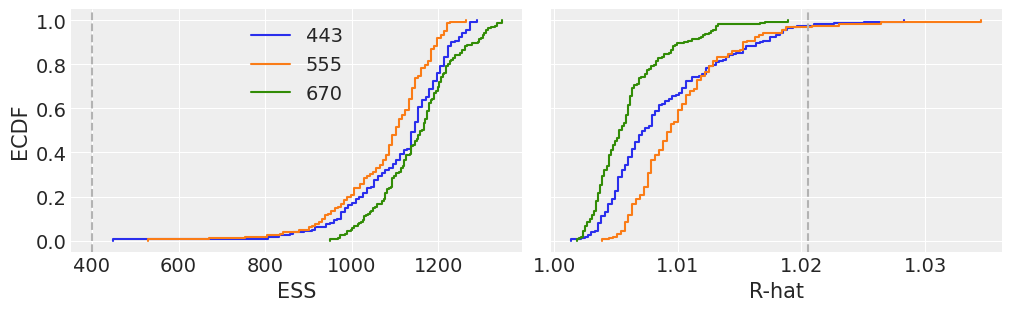

In [41]:
axs = pmb.plot_convergence(idata=idata_aph, var_name='μ', )
axs[0].set_ylabel('ECDF')
legend_handles = [
    Line2D([0], [0], color='C0', label='443'),
    Line2D([0], [0], color='C1',label='555'),
    Line2D([0], [0], color='C2',label='670')
]
axs[0].legend(handles=legend_handles)
f = pp.gcf()
f.savefig(image_save_path/'model1_bart_convergence.png', dpi=300)
f.savefig(image_save_path/'model1_bart_convergence.pdf', dpi=300)

The desired outcome is for the ESS plot lines (left) to be greater than the limit suggested by the dashed line, and less than the dashed line for the $\hat{R}$ plot (right). This satisfied for ESS and mostly satsified for the $\hat{R}$.

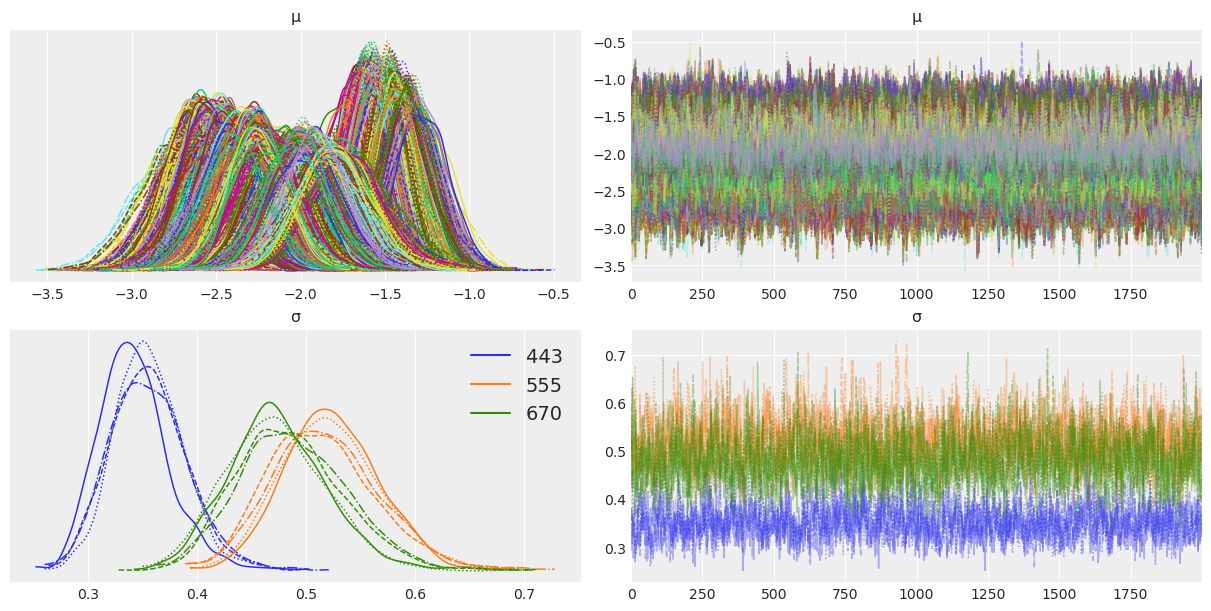

In [42]:
f, axs = pp.subplots(2, 2, figsize=(12, 6))
az.plot_trace(idata_aph, axes=axs)
axs.ravel()[2].legend(handles=legend_handles)
f = pp.gcf()
f.savefig(image_save_path / 'm1_bart_trace.png', dpi=300)
f.savefig(image_save_path / 'm1_bart_trace.pdf', dpi=300)

Traces do not show obvious patterns or trends, suggesting well-mixed chains, indicative of adquate sampling. This concludes the section on model fitting diagnostics.


## Model Post-Fit Analysis

Having verified that PyMC did an good job sampling the posterior I analyze how well the model has learned. But first, a few helper functions defined below:

In [43]:
def plot_regression_hdi(idata):
    y_hat_94 = az.hdi(
        idata.posterior_predictive.likelihood).likelihood.to_numpy()
    y_hat_63 = az.hdi(
        idata.posterior_predictive.likelihood, hdi_prob=0.63).likelihood.to_numpy()
    y = idata.observed_data.likelihood.to_numpy()
    x = np.arange(y.size)
    idx = np.argsort(y)

    f, ax = pp.subplots(figsize=(12, 8))
    ax.fill_between(x=x, y1 = y_hat_94[idx, 0], y2=y_hat_94[idx, 1], color='black', label='94% HDI')
    ax.fill_between(x=x, y1=y_hat_63[idx, 0], y2=y_hat_63[idx, 1 ], color='darkgray', label='63% HDI')
    ax.scatter(x, y[idx], s=30, color='red', label='observed')
    ax.legend()
    ax.set_xlabel('observation #')
    ax.set_ylabel(r'$a_φ(443)$')
    return f, ax

In [44]:
def plot_3_way_ppc(idata, colors=['darkgray', 'k', 'C1'], kind='kde', include_all=True):
    if include_all:
        f, axs = pp.subplots(ncols=2, nrows=2, figsize=(8, 8), sharex=True, sharey=True)
        ax = axs.ravel()[-1]
        ax.set_title('All targets')
        az.plot_ppc(idata, ax=axs.ravel()[-1], colors=colors, kind=kind)
        ax.set_xlabel(f'log(aφ)')
    else:
        f, axs= pp.subplots(ncols=3, figsize=(13, 4), sharex=True, sharey=True)
    bands = ['443', '555', '670']
    for i, (ax, band) in enumerate(zip(axs.ravel(), bands)):
        az.plot_ppc(
            idata, coords={'λ_aφ': band }, ax=ax, colors=colors, kind=kind, legend=False)
        ax.set_title(f'λ = {band}')
        if i==2:
            ax.set_xlabel(f'log(aφ)')
    return f, ax

Next is to simulate $log(aΦ)$ from the posterior; posterior predictive checks

In [45]:
with m_aph:
    idata_aph.extend(pm.sample_posterior_predictive(idata_aph))

Sampling: [likelihood]


Output()

Did the model learn: comparing prior and posterior predictive checks

In [332]:
def compare_ppc(
        idata:az.InferenceData, ax0_xlims:tuple|None=None, ax1_xlims:tuple|None=None,
        ax0_ylims:tuple|None=None, ax1_ylims:tuple|None=None):
    """Function to create comparative plot between prior and posterior ppc"""
    f, ax= pp.subplots(ncols=2, figsize=(8, 5), sharex=True)
    az.plot_ppc(idata, group='prior', observed=True, ax=ax[0], colors=['darkgray', 'k', 'C1'])
    az.plot_ppc(idata, ax=ax[1], colors=['darkgray', 'k', 'C1'])
    if ax0_xlims is not None:
        ax[0].set_xlim(ax0_xlims[0], ax0_xlims[1])
    if ax1_xlims is not None:
        ax[1].set_xlim(ax1_xlims[0], ax1_xlims[1])
    if ax0_ylims is not None:
        ax[0].set_ylim(ax0_ylims[0], ax0_ylims[1])
    if ax1_ylims is not None:
        ax[1].set_ylim(ax1_ylims[0], ax1_ylims[1])
    return f, ax

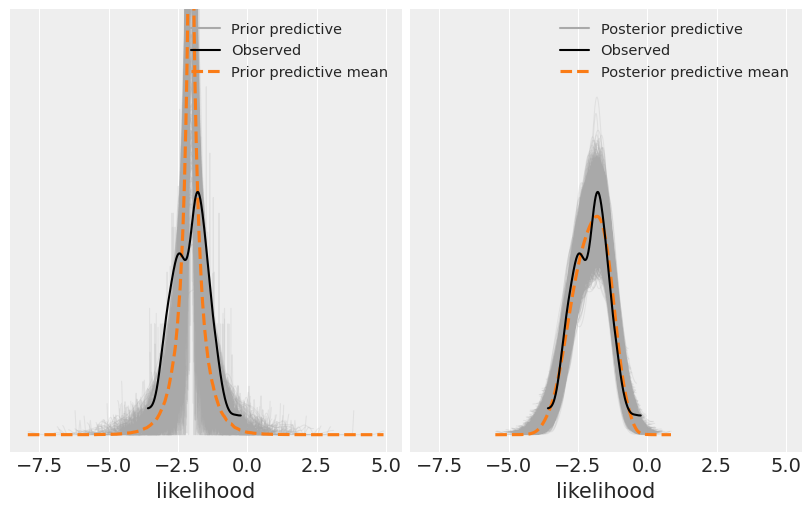

In [336]:
f1, ax1 = compare_ppc(idata_aph, 
                      ax0_ylims=((-0.04284270793147993, 0.8996968665610785*1.2)),
                      ax1_ylims=((-0.04284270793147993, 0.8996968665610785*1.2))
                      )

The simulated data is much closer to the observations. The uncertainty captures the skewed bimodal nature of the data. Note that the simulated data is monomodal because I gave the model a Gaussian likelihood. I don't feel comfortable proposing a more complex likelihood, as the bimodality could be an artifact of the data paucity. This can be updated later as more data comes and the need to change the likelihood becomes apparent. For now the posterior predictive checks (on the right), suggests the model approximates the data generation process quite well. Next, I examine the same posterior predictive checks for each of the 3 phytoplankton absorption (aφ) bands.

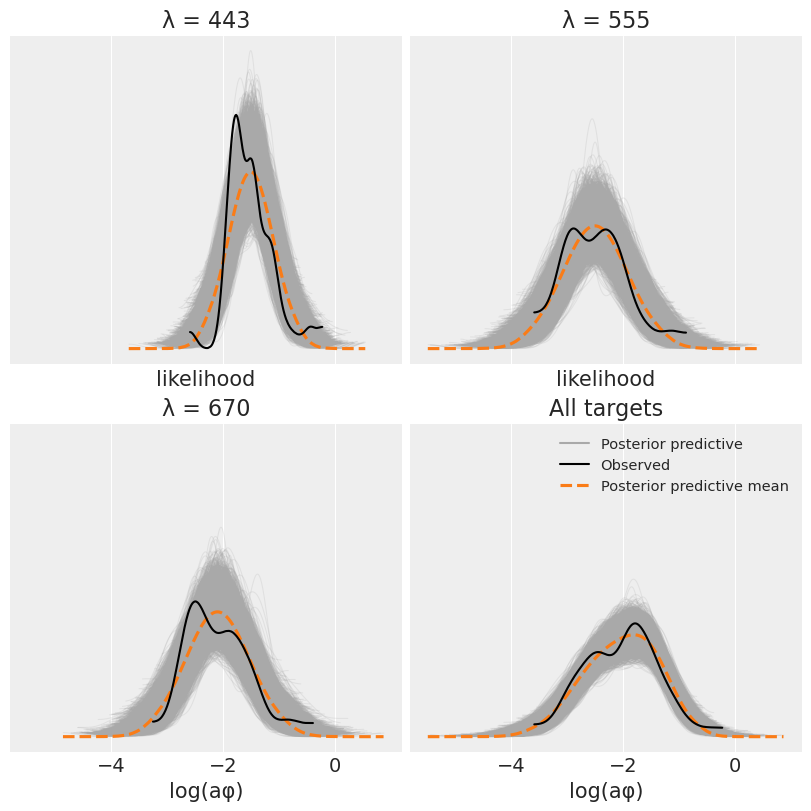

In [48]:
f, ax = plot_3_way_ppc(idata_aph, include_all=True)
f.savefig(image_save_path / 'm1_3_way_ppc.png', dpi=300)
f.savefig(image_save_path / 'm1_3_way_ppc.pdf', dpi=300)

Another useful view of the above is the empirical cumulative distribution function, below.

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_98221/4078440884.py:2: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  f.savefig(image_save_path / 'm1_3_way_ppc_cdf.png', dpi=300)
/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_98221/4078440884.py:3: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  f.savefig(image_save_path / 'm1_3_way_ppc_cdf.pdf', dpi=300)
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


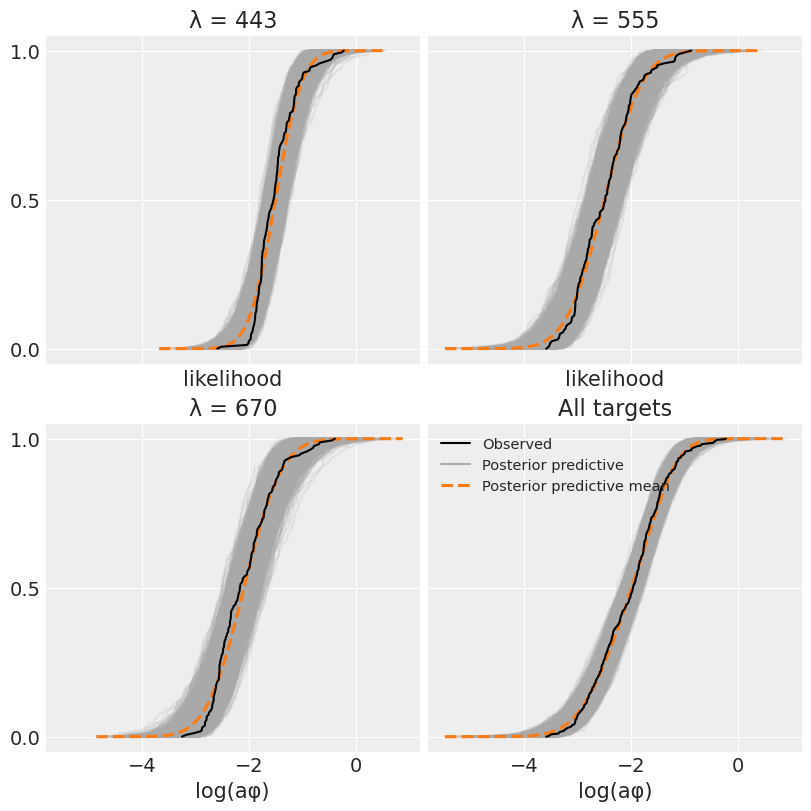

In [50]:
f, ax = plot_3_way_ppc(idata_aph, kind='cumulative', include_all=True)
f.savefig(image_save_path / 'm1_3_way_ppc_cdf.png', dpi=300)
f.savefig(image_save_path / 'm1_3_way_ppc_cdf.pdf', dpi=300)

#### A quick look at band-specific variance
This hows that aφ(555), and aφ(670) are similarly dispersed, and similarly uncertain. The variance of aφ(443) is smaller and less uncertain

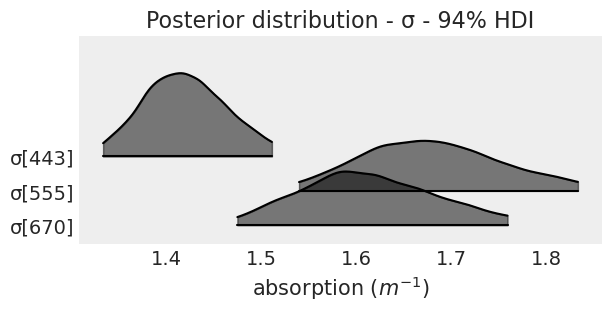

In [58]:
f, ax = pp.subplots(figsize=(6, 3))
az.plot_forest(idata_aph, kind='ridgeplot', ridgeplot_alpha=0.5, var_names='σ', ax=ax, combined=True, transform=np.exp, colors='k' )
ax.set_yticklabels(['σ[670]', 'σ[555]', 'σ[443]']);
ax.set_title('Posterior distribution - σ - 94% HDI')
ax.set_xlabel(r'absorption ($m^{-1}$)')
f.savefig(image_save_path / 'm1_σ_forest.png', dpi=300)
f.savefig(image_save_path / 'm1_σ_forest.pdf', dpi=300)

The plot above (rescaled to linear units of absorption) shows significant differences between 443 and the other two bands. 555 and 670 are on the other hand are for practical purposes indistinguishable from one another.


### Partial Conditional Dependence

PDPs show average feature-wise effects. In particular we'll see if 
1. Different TOA radiances carry wavelength-specific information about the underlying IOPs (inherent optical properties);
2. The strength and direction of their effect on predicted aph changes with wavelength


/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_98221/2362500510.py:21: UserWarning: The figure layout has changed to tight
  f.tight_layout()


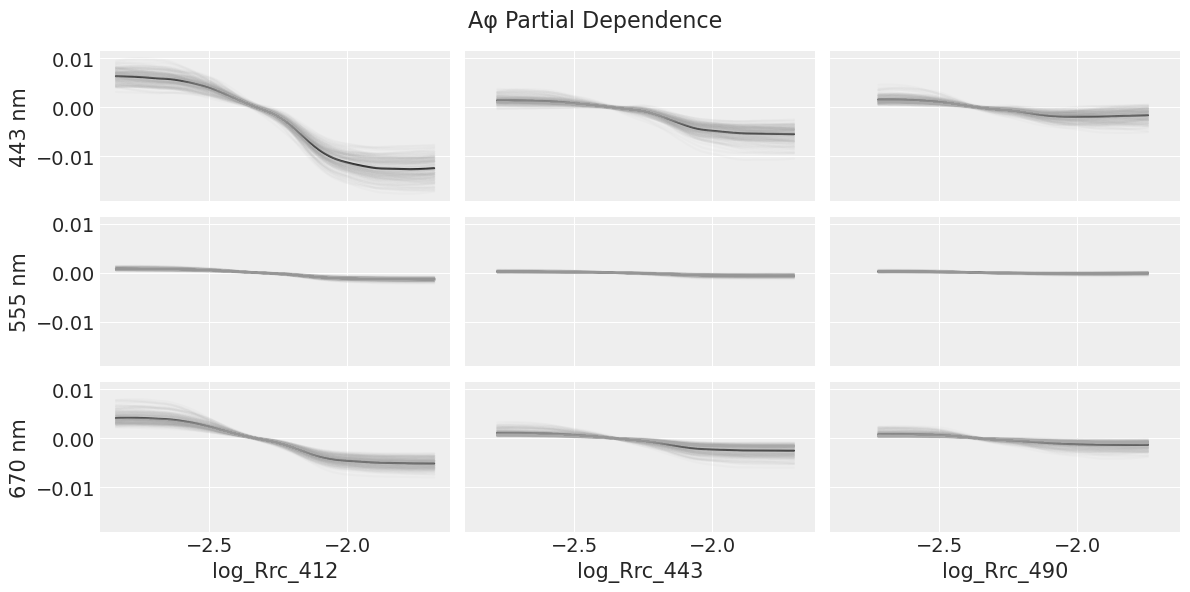

In [102]:
func=lambda x: 10**x
f, axs = pp.subplots(nrows=3, ncols=3, figsize=(12, 6), sharex=True, sharey=True)
axs_0 = axs[:, 0]
axs_1 = axs[:, 1]
axs_2 = axs[:, 2]
pmb.plot_ice(
    m_aph.μ, X, Y, var_idx=[0], instances=150, color='darkgray', color_mean='k', alpha=0.05, ax=axs_0, func=func)
pmb.plot_ice(
    m_aph.μ, X, Y, var_idx=[1], instances=150, color='darkgray', color_mean='k', alpha=0.05, ax=axs_1, func=func)
pmb.plot_ice(
    m_aph.μ, X, Y, var_idx=[2], instances=150, color='darkgray', color_mean='k', alpha=0.05, ax=axs_2, func=func)
for i, (ax0, ax1, ax2, l) in enumerate(zip(axs_0, axs_1, axs_2, coords['λ_aφ'])):
    ax0.set_ylabel(f'{l} nm')  # Get the current figure
    if i<2: 
        ax0.set_xlabel('')
        ax1.set_xlabel('')
        ax2.set_xlabel('')

f.texts.clear()
f.suptitle("Aφ Partial Dependence", fontsize=16)
f.tight_layout()


For the first three wavelengths of TOA randiances (Rrc) (412 ,443, 490), we see a monotonically down sloping impact on phytoplankton absorption with increasing Rrc values. Thus Rrc contributes to positive values in aφ at low log Rrc values, and negative values in aφ at higher Rrc values. This trend is most apparent for Aφ(443), and least apparetn for Aφ(555). For all 3 Rrc wavelengths, there is a 0-crossing between -2.5 and -2.0 in log-space. 

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_98221/2792215906.py:20: UserWarning: The figure layout has changed to tight
  f.tight_layout()


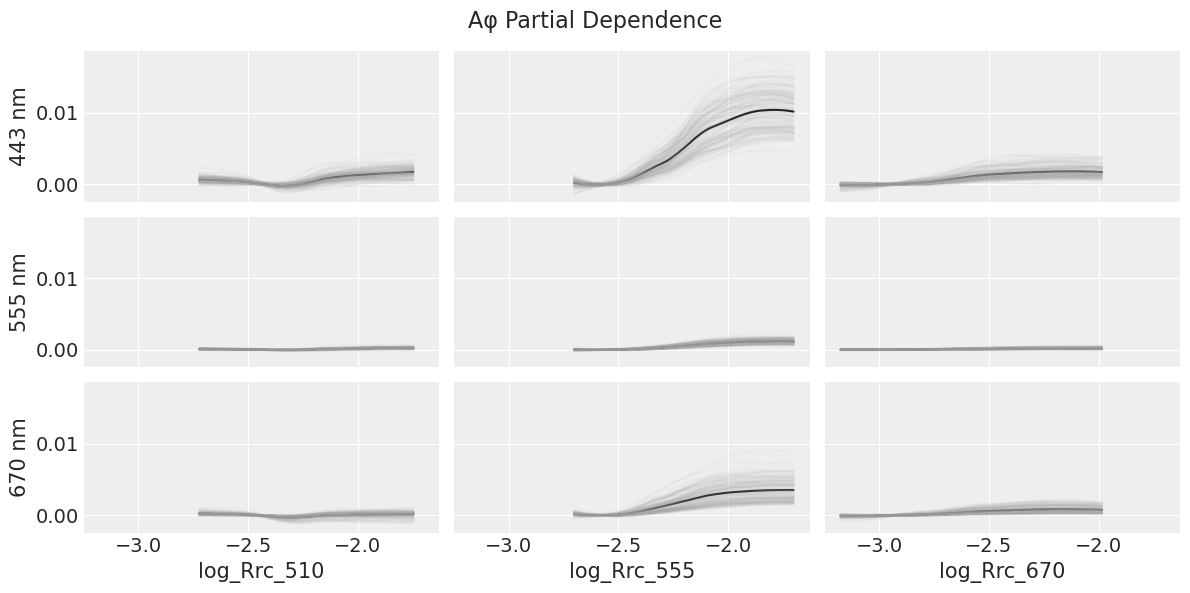

In [103]:
f, axs = pp.subplots(nrows=3, ncols=3, figsize=(12, 6), sharex=True, sharey=True)
axs_0 = axs[:, 0]
axs_1 = axs[:, 1]
axs_2 = axs[:, 2]
pmb.plot_ice(
    m_aph.μ, X, Y, var_idx=[3], instances=150, color='darkgray', color_mean='k', alpha=0.05, ax=axs_0, func=func)
pmb.plot_ice(
    m_aph.μ, X, Y, var_idx=[4], instances=150, color='darkgray', color_mean='k', alpha=0.05, ax=axs_1, func=func)
pmb.plot_ice(
    m_aph.μ, X, Y, var_idx=[5], instances=150, color='darkgray', color_mean='k', alpha=0.05, ax=axs_2, func=func)
for i, (ax0, ax1, ax2, l) in enumerate(zip(axs_0, axs_1, axs_2, coords['λ_aφ'])):
    ax0.set_ylabel(f'{l} nm')  # Get the current figure
    if i<2: 
        ax0.set_xlabel('')
        ax1.set_xlabel('')
        ax2.set_xlabel('')

f.texts.clear()
f.suptitle("Aφ Partial Dependence", fontsize=16)
f.tight_layout()

The trend noted earlier is mostly reversed here for Rrc at wavelengths 510, 555, 670, though not always cleanly monotonic. Indeed, for Rrc(510), we see an initally downsloping trend, reversed shortly after the zero-crossing between -2.5, and -2.0 in log-space. Upon hitting a mimimum, the trend is reversed. Greatest effect is observed in the impact of Rrs(555). While PDP are useful in synthesizing average feature impact on predictions, it can be instructive to observe impact of individual observations on corresponding outputs. That is where Individual Conditional Expectation (ICE - the useful kind) comes in.

### Individual Conditional Expectation

array([<Axes: xlabel='log_Rrc_412'>, <Axes: xlabel='log_Rrc_412'>,
       <Axes: xlabel='log_Rrc_412'>], dtype=object)

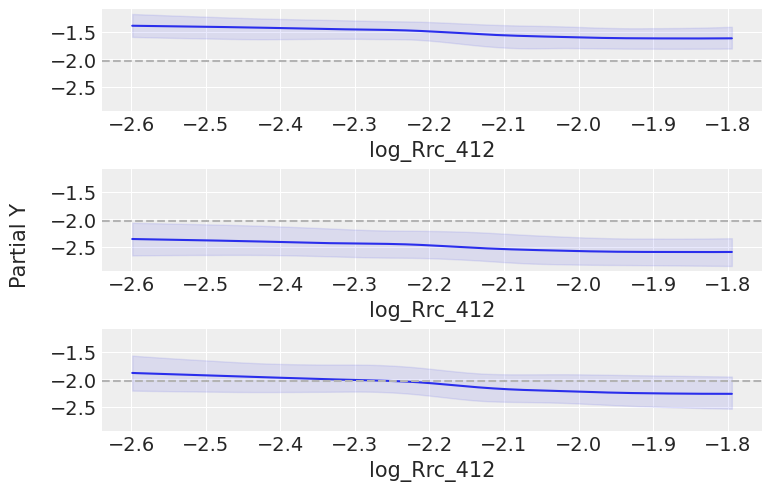

In [156]:

pmb.plot_pdp(m_aph['μ'], X, Y, var_idx=[0])

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_98221/2505091679.py:21: UserWarning: The figure layout has changed to tight
  f.tight_layout()


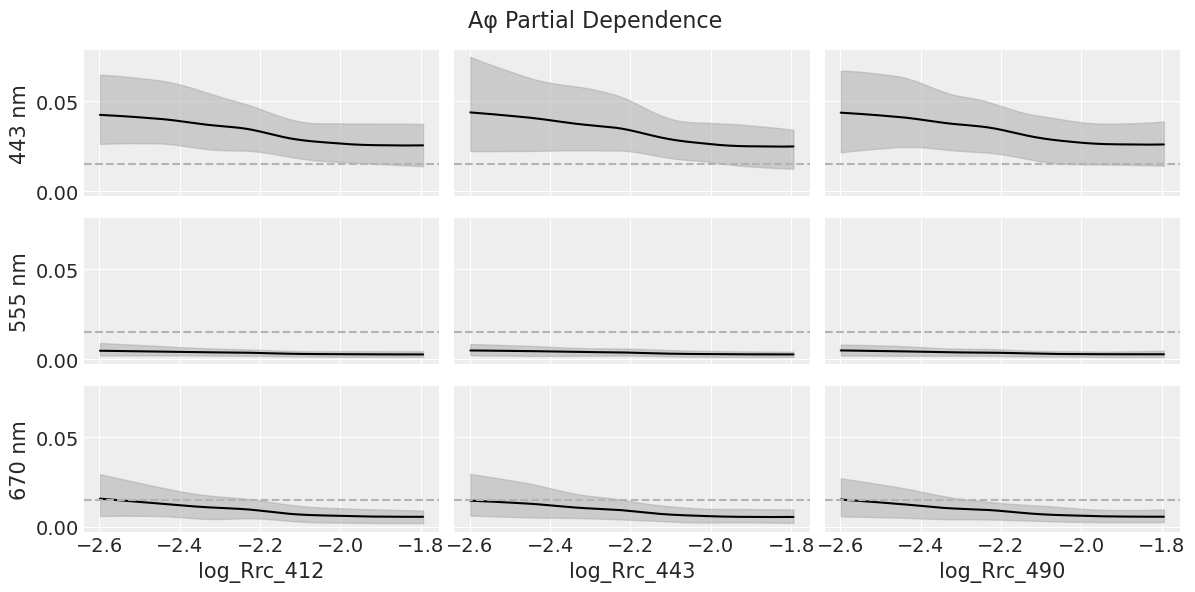

In [158]:
f, axs = pp.subplots(nrows=3, ncols=3, figsize=(12, 6), sharex=True, sharey=True)
axs_0 = axs[:, 0]
axs_1 = axs[:, 1]
axs_2 = axs[:, 2]

pmb.plot_pdp(
    m_aph.μ, X, Y, var_idx=[0], color='darkgray', color_mean='k', alpha=0.5, ax=axs_0, func=func)
pmb.plot_pdp(
    m_aph.μ, X, Y, var_idx=[1], color='darkgray', color_mean='k', alpha=0.5, ax=axs_1, func=func)
pmb.plot_pdp(
    m_aph.μ, X, Y, var_idx=[2], color='darkgray', color_mean='k', alpha=0.5, ax=axs_2, func=func)
for i, (ax0, ax1, ax2, l) in enumerate(zip(axs_0, axs_1, axs_2, coords['λ_aφ'])):
    ax0.set_ylabel(f'{l} nm')  # Get the current figure
    if i<2: 
        ax0.set_xlabel('')
        ax1.set_xlabel('')
        ax2.set_xlabel('')

f.texts.clear()
f.suptitle("Aφ Partial Dependence", fontsize=16)
f.tight_layout()

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_98221/14048162.py:21: UserWarning: The figure layout has changed to tight
  f.tight_layout()


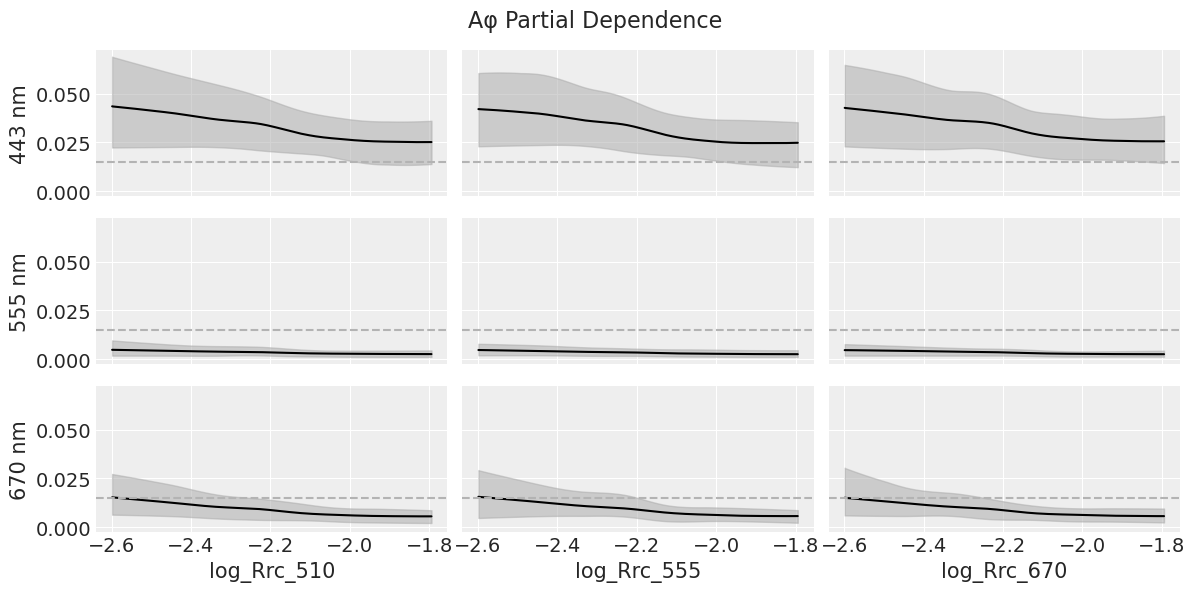

In [159]:
f, axs = pp.subplots(nrows=3, ncols=3, figsize=(12, 6), sharex=True, sharey=True)
axs_0 = axs[:, 0]
axs_1 = axs[:, 1]
axs_2 = axs[:, 2]

pmb.plot_pdp(
    m_aph.μ, X, Y, var_idx=[3], color='darkgray', color_mean='k', alpha=0.5, ax=axs_0, func=func)
pmb.plot_pdp(
    m_aph.μ, X, Y, var_idx=[4], color='darkgray', color_mean='k', alpha=0.5, ax=axs_1, func=func)
pmb.plot_pdp(
    m_aph.μ, X, Y, var_idx=[5], color='darkgray', color_mean='k', alpha=0.5, ax=axs_2, func=func)
for i, (ax0, ax1, ax2, l) in enumerate(zip(axs_0, axs_1, axs_2, coords['λ_aφ'])):
    ax0.set_ylabel(f'{l} nm')  # Get the current figure
    if i<2: 
        ax0.set_xlabel('')
        ax1.set_xlabel('')
        ax2.set_xlabel('')

f.texts.clear()
f.suptitle("Aφ Partial Dependence", fontsize=16)
f.tight_layout()

### Variable Importance

[Text(0, 0, 'log_Rrc_412'),
 Text(1, 0, '+ log_Rrc_555'),
 Text(2, 0, '+ log_Rrc_443'),
 Text(3, 0, '+ log_Rrc_490'),
 Text(4, 0, '+ log_Rrc_510'),
 Text(5, 0, '+ log_Rrc_670')]

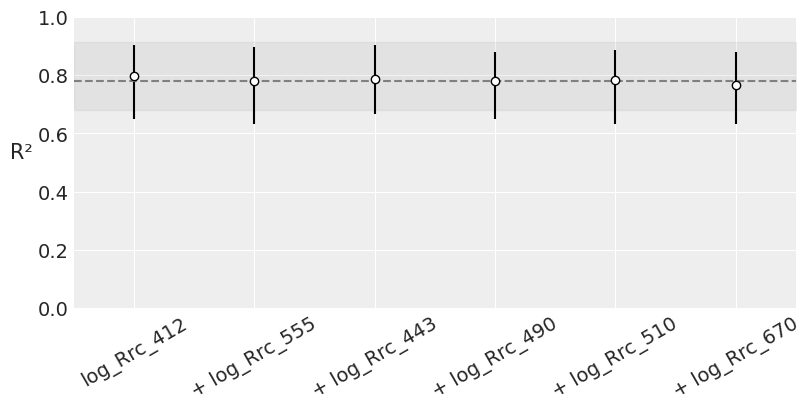

In [164]:
f, ax= pp.subplots(figsize=(8, 4))
vi_results = pmb.compute_variable_importance(idata_aph, m_aph.μ, X, samples=100)
pmb.plot_variable_importance(vi_results, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30);

None of the input features is more important in predictive power. Thus the model's skill comes from leverageing feature interactions. I assess the model's genearlization (out-of-sample predictive power) next

## Model Generalization, the LOO-PIT Approach

When working with limited data, holding out a test set to assess predictive performance isn’t practical. Instead, leave-one-out cross-validation (LOO) provides a principled way to estimate out-of-sample predictive accuracy without sacrificing data. One powerful diagnostic that builds on this is the **Leave-One-Out Probability Integral Transform**; LOO-PIT. LOO-PIT evaluates how well-calibrated the model’s predictive distributions are. If the model generalizes well, the LOO-PIT values should follow a uniform distribution—deviations from uniformity reveal whether the model tends to be overconfident (narrow intervals), underconfident (wide intervals), or systematically biased. This makes LOO-PIT especially valuable for small datasets, where it serves as a rigorous stand-in for test-set validation and helps diagnose both predictive accuracy and uncertainty calibration.

In [166]:
vi_results['r2_mean']

array([0.79755316, 0.78008152, 0.78644   , 0.77952838, 0.78288302,
       0.76533577])

In [177]:
with m_aph:
    try:
        _ = pm.compute_log_likelihood(idata_aph, extend_inferencedata=True)
    except ValueError:
        pass

Output()

In [178]:
loo_results = az.loo(idata_aph)
print(loo_results)

/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 8000 posterior samples and 489 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -337.89    20.55
p_loo       74.92        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      487   99.6%
   (0.70, 1]   (bad)         2    0.4%
   (1, Inf)   (very bad)    0    0.0%



In [179]:
loo = az.loo(idata_aph, pointwise=True)
k_values = loo.pareto_k.values
influential_idx = (k_values > 0.7).nonzero()[0]
print("Influential observations:", influential_idx)

Influential observations: [  5 138]


/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


The above suggests an overdispersed model. One way to try to fix this is to introduce a hierarchical structure to infer σ.

In [246]:
with pm.Model(coords=coords) as m_aph_2:
    X_data = pm.Data('log_Rrc', X, dims=['obs_idx', 'λ_toa'])
    Y_data = pm.Data('log_aφ', Y, dims=['obs_idx', 'λ_aφ'])
    σ_λ = pm.Exponential("σ_λ", 0.1)  # vague prior, median = log(2) ≈ 0.69
    σ = pm.Exponential("σ", lam=σ_λ, dims='λ_aφ')
    μ = pmb.BART('μ', X=X_data, Y=Y_data, m=10, alpha=0.9, beta=4, dims=('λ_aφ', 'obs_idx')).T
    pm.Normal('likelihood', mu=μ, sigma=σ, observed=Y_data, dims=['obs_idx', 'λ_aφ'])

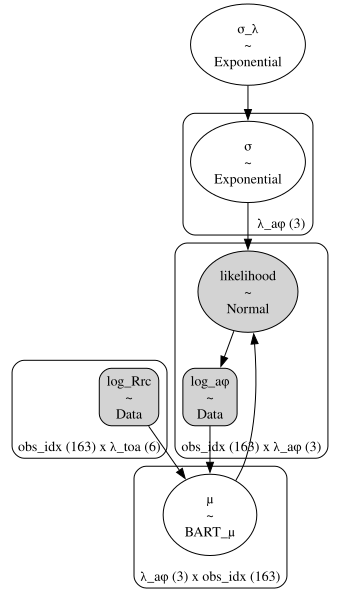

In [247]:
m_aph_2.to_graphviz()

In [248]:
with m_aph_2:
    idata_aph_2 = pm.sample_prior_predictive()

Sampling: [likelihood, μ, σ, σ_λ]


In [251]:
with m_aph_2:
    idata_aph_2.extend(pm.sample(chains=4, tune=3000, draws=2000, target_accept=0.95, ))

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [σ_λ, σ]
>PGBART: [μ]


Output()

Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 10 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [253]:
az.summary(idata_aph_2, kind='diagnostics').r_hat.value_counts(normalize=True)

r_hat
1.01    0.492901
1.00    0.403651
1.02    0.050710
1.03    0.032454
1.04    0.018256
1.05    0.002028
Name: proportion, dtype: float64

array([[<Axes: title={'center': 'σ_λ'}>, <Axes: title={'center': 'σ_λ'}>],
       [<Axes: title={'center': 'σ'}>, <Axes: title={'center': 'σ'}>]],
      dtype=object)

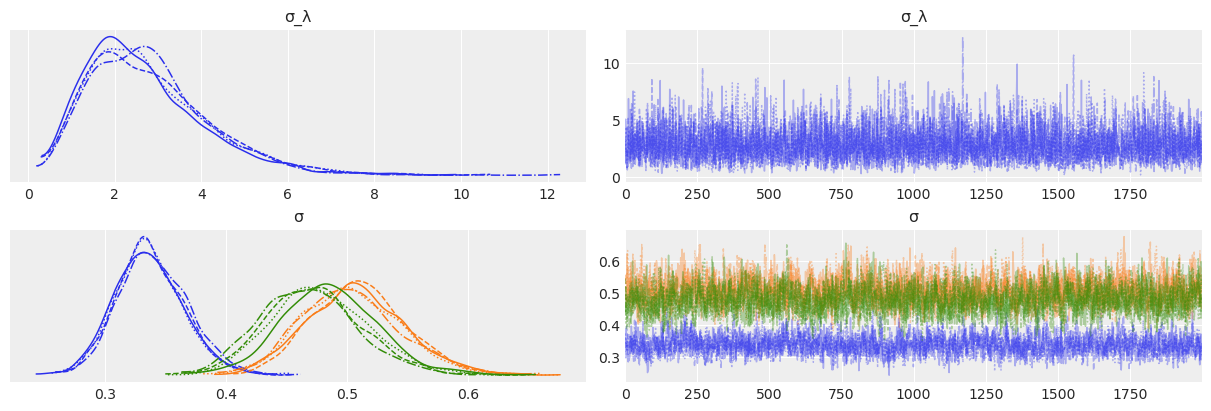

In [254]:
az.plot_trace(idata_aph_2, var_names=['σ_λ', 'σ'])

In [255]:
with m_aph_2:
    idata_aph_2.extend(pm.sample_posterior_predictive(idata_aph_2))

Sampling: [likelihood]


Output()

In [256]:
with m_aph_2:
    pm.compute_log_likelihood(idata_aph_2, extend_inferencedata=True)

Output()

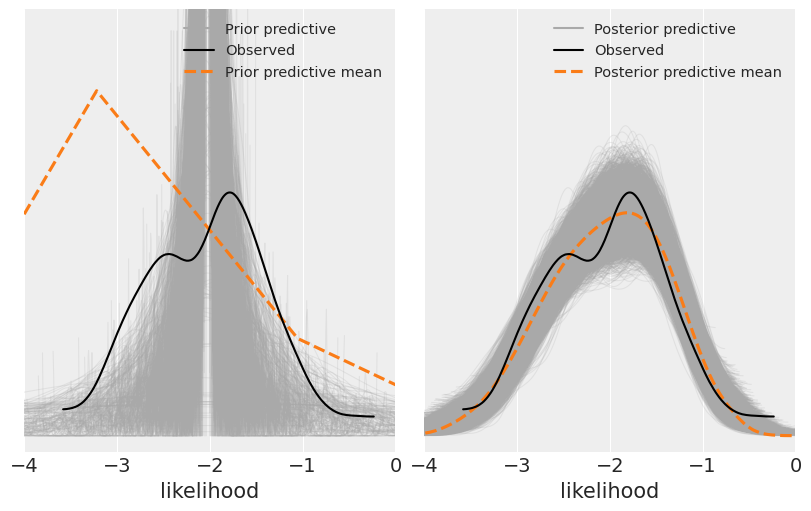

In [342]:
f2, ax2 = compare_ppc(idata_aph_2,
                      ax0_xlims=((-8, 4)),
                      ax1_xlims=((-4, 0)), 
                      ax0_ylims=((-0.04, 0.9*1.2)),
                      ax1_ylims=((-0.04, 0.9*1.2))
                      )

In [258]:
loo_results_2 = az.loo(idata_aph_2)

In [259]:
loo_results_2

Computed from 8000 posterior samples and 489 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -312.34    20.37
p_loo       51.94        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      489  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

<Axes: xlabel='likelihood'>

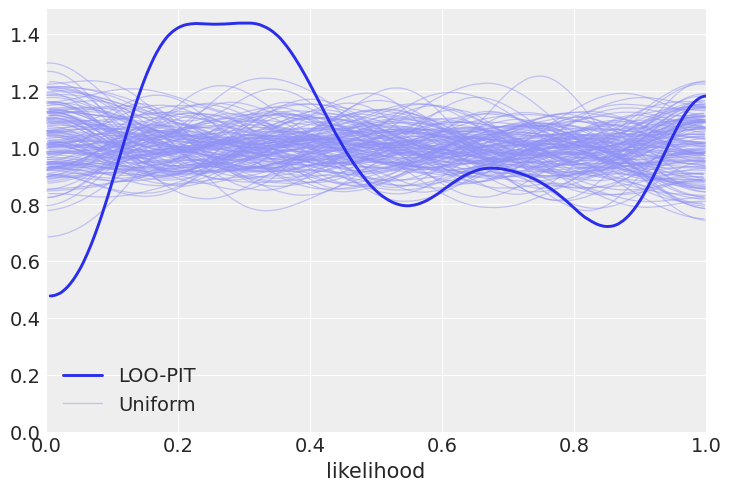

In [260]:
az.plot_loo_pit(idata_aph_2, y='likelihood', y_hat='likelihood', n_unif=150)

This suggest overdipersion again. I think now I have to start thinking about .

### Model #3 Pooled model with Heteroscedasticity

In [319]:
with pm.Model(coords=coords) as m_aph_3:
    X_data = pm.Data('log_Rrc', X, dims=['obs_idx', 'λ_toa'])
    Y_data = pm.Data('log_aφ', Y, dims=['obs_idx', 'λ_aφ'])

    # ---- model mean ---    
    μ = pmb.BART('μ', X=X_data, Y=Y_data, m=10, dims=('λ_aφ', 'obs_idx')).T

    # ---- model heteroscedastic noise
    w = pm.Normal('w', 0, .11, dims=['λ_toa', 'λ_aφ']) # noise slopes
    b = pm.Normal('b', 0, .11, dims=['λ_aφ'])
    log_σ = pm.Deterministic('log_σ', X_data@w + b)
    
    pm.Normal('likelihood', mu=μ, sigma=pm.math.exp(log_σ), observed=Y_data, dims=['obs_idx', 'λ_aφ'])

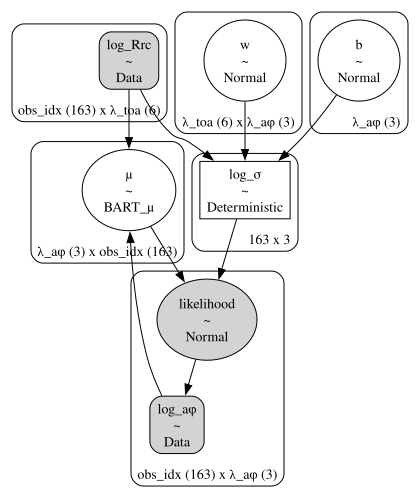

In [414]:
g3 = m_aph_3.to_graphviz()
g3

In [311]:
with m_aph_3:
    idata_aph_3 = pm.sample_prior_predictive()

Sampling: [b, likelihood, w, μ]


In [321]:
with m_aph_3:
    idata_aph_3.extend(pm.sample(draws=2000, tune=1000, chains=4))

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>PGBART: [μ]
>NUTS: [w, b]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 15 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [326]:
az.summary(idata_aph_3, kind='diagnostics').r_hat.value_counts(normalize=True).round(3) * 100

r_hat
1.01    56.5
1.00    42.1
1.02     1.4
Name: proportion, dtype: float64

array([[<Axes: title={'center': 'μ'}>, <Axes: title={'center': 'μ'}>],
       [<Axes: title={'center': 'w'}>, <Axes: title={'center': 'w'}>],
       [<Axes: title={'center': 'b'}>, <Axes: title={'center': 'b'}>],
       [<Axes: title={'center': 'log_σ'}>,
        <Axes: title={'center': 'log_σ'}>]], dtype=object)

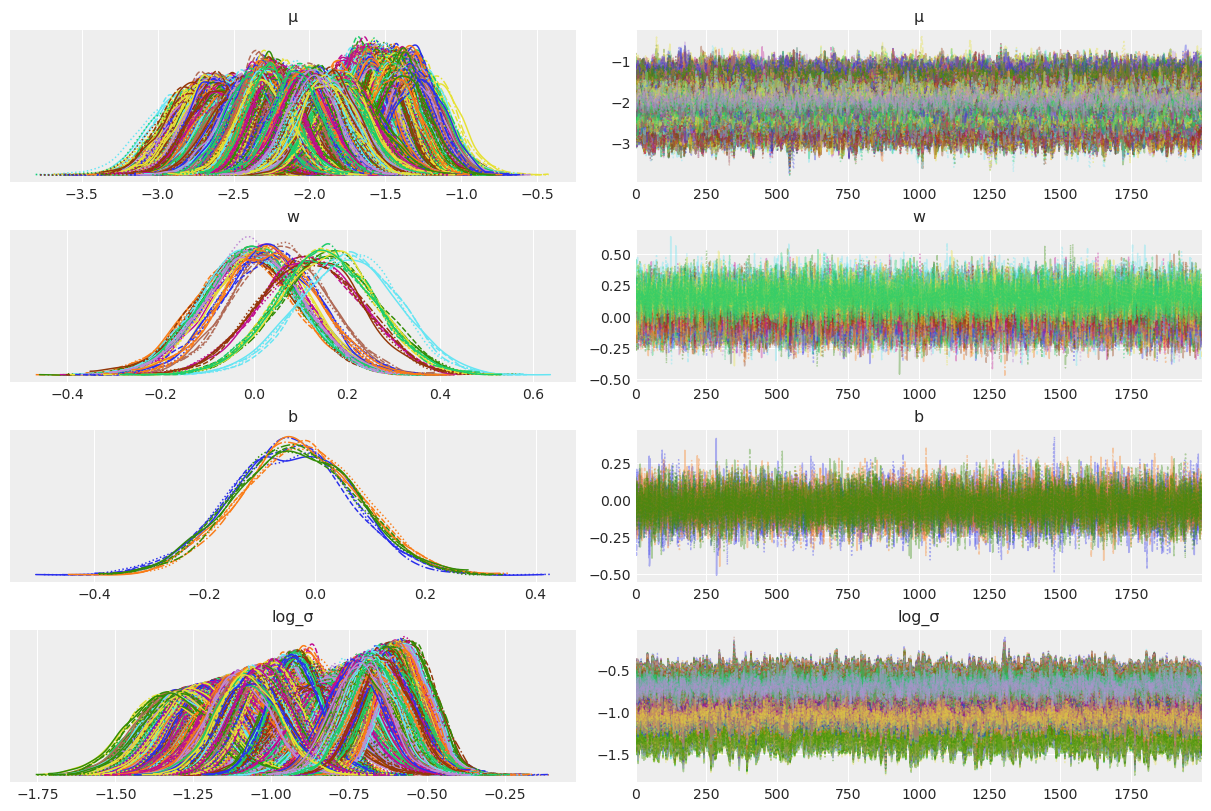

In [327]:
az.plot_trace(idata_aph_3)

In [328]:
with m_aph_3:
    idata_aph_3.extend(pm.sample_posterior_predictive(idata_aph_3))

Sampling: [likelihood]


Output()

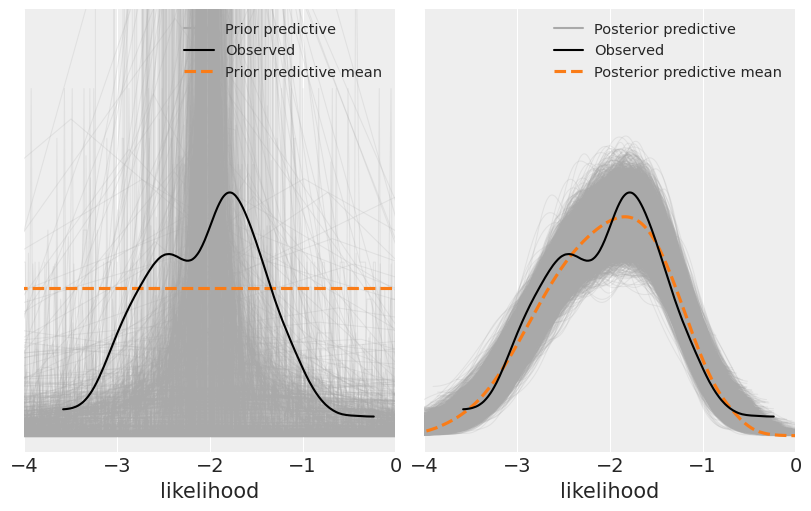

In [341]:
f3, ax3 = compare_ppc(idata_aph_3,
                      ax0_xlims=((-8, 4)),
                      ax1_xlims=((-4, 0)), 
                      ax0_ylims=((-0.04, 0.9*1.2)),
                      ax1_ylims=((-0.04, 0.9*1.2))
                      )

Shows good learning

In [329]:
with m_aph_3:
    pm.compute_log_likelihood(idata_aph_3, extend_inferencedata=True)

Output()

In [408]:
def plot_ppc_pit(idata):

    ppc_colors= ['darkgray', 'k', 'C1']
    pit_xlabel= r'$\text{PIT}(y_i \mid y_{-i})$'
    f = pp.figure(figsize=(10, 7))
    ax_ppc = f.add_subplot(211)
    ax_ppc.set_title('Posterior Predictive Checks')
    az.plot_ppc(idata, ax=ax_ppc, colors=ppc_colors)
    ax_ppc.set_ylabel('Estimated Density')
    ax_ppc.set_xticklabels([])
    ax_loo_pit = f.add_subplot(223)
    az.plot_loo_pit(idata, y='likelihood', ax=ax_loo_pit, legend=True)
    ax_loo_pit.set_xlabel(pit_xlabel)
    ax_loo_pit.set_ylabel('Estimated Density')
    ax_loo_pit.set_title('Model LOO-PIT')
    ax_lp_ecdf = f.add_subplot(224)
    az.plot_loo_pit(idata, y='likelihood', ax=ax_lp_ecdf, ecdf=True, legend=True)
    ax_lp_ecdf.set_xlabel(pit_xlabel)
    ax_lp_ecdf.set_ylabel('Deviation from Uniform CDF')
    ax_lp_ecdf.set_title('Model LOO-PIT ECDF Deviation')
    f.tight_layout()
    return dict(fig_handle=f, ppc_ax_hdl=ax_ppc, pit_ax_hdl=ax_loo_pit, pit_ecdf_ax_hdl=ax_lp_ecdf)

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_98221/6069476.py:21: UserWarning: The figure layout has changed to tight
  f.tight_layout()


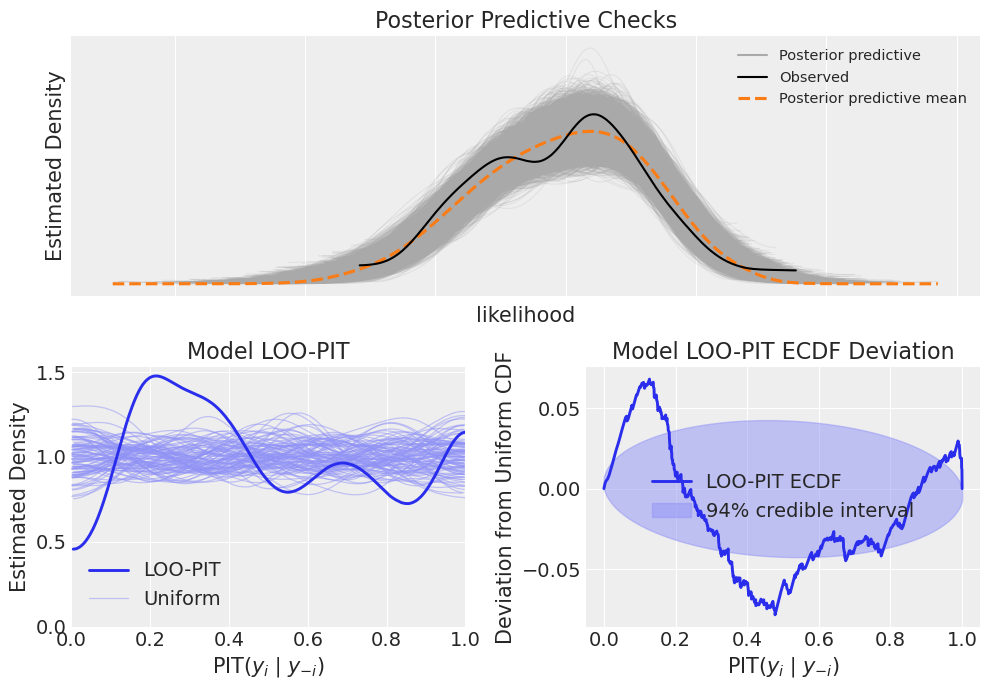

In [409]:
fig_pyld_m1 = plot_ppc_pit(idata_aph)

In [ ]:
f1 = fig_pyld_m1['fig_handle']
f1.savefig('./figures/model1_loo_pit.png', dpi=300)

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_98221/6069476.py:21: UserWarning: The figure layout has changed to tight
  f.tight_layout()


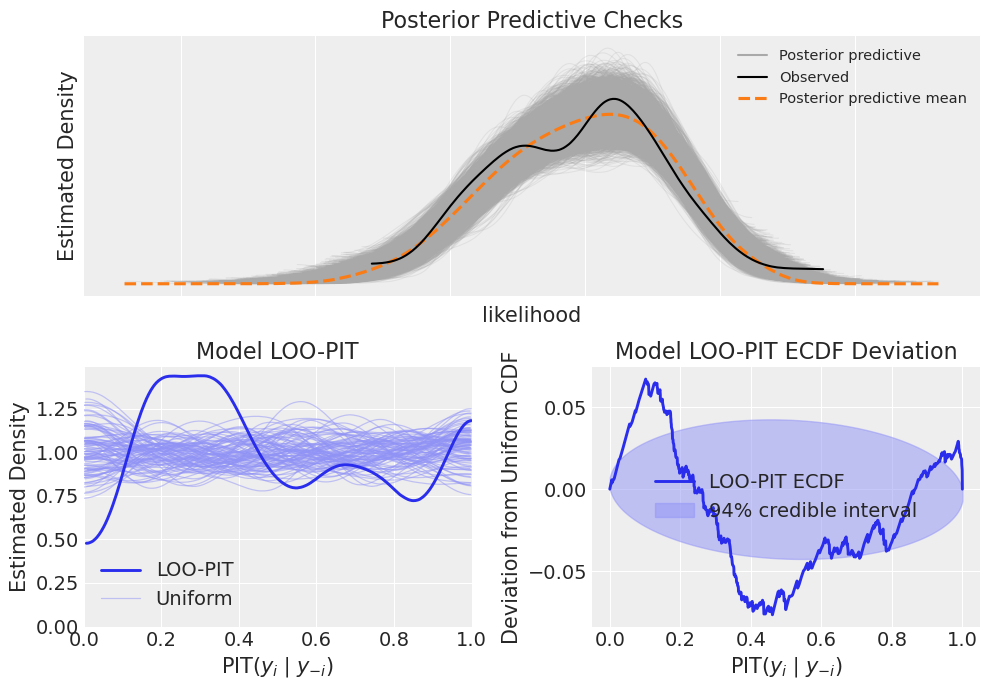

In [410]:
fig_pyld_m2 = plot_ppc_pit(idata_aph_2)

In [411]:
f2 = fig_pyld_m2['fig_handle']
f2.savefig('./figures/model2_loo_pit.png', dpi=300)

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_98221/6069476.py:21: UserWarning: The figure layout has changed to tight
  f.tight_layout()
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


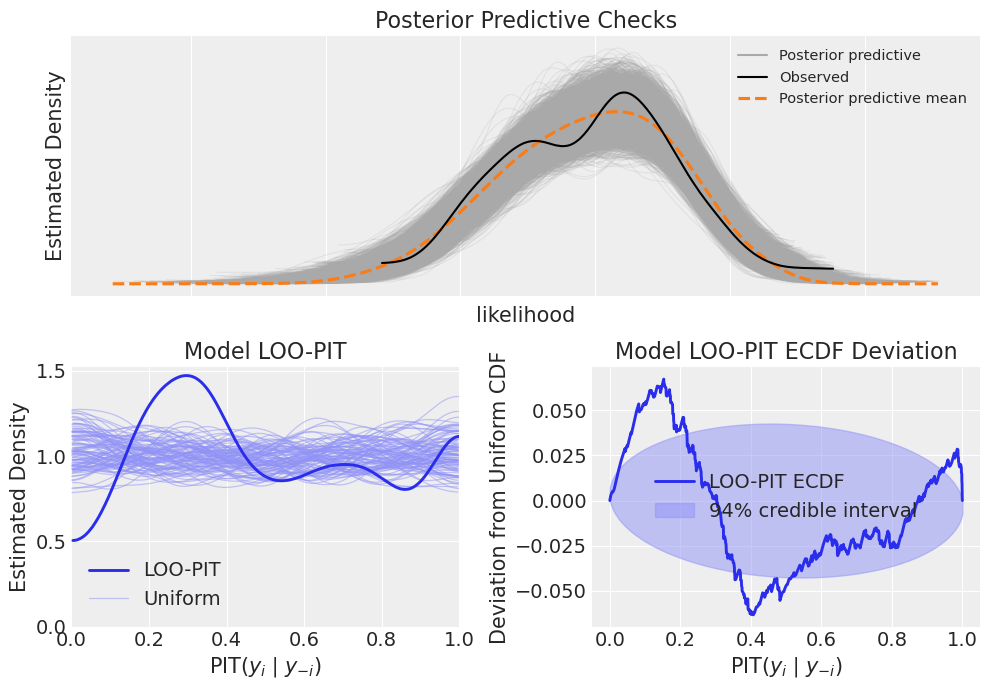

In [412]:
fig_pyld_m3 = plot_ppc_pit(idata_aph_3)

In [415]:
f3 = fig_pyld_m3['fig_handle']
f3.savefig('./figures/model3_loo_pit.png', dpi=300)

## Calibration Results

### 1. On Calibration and Limited Data
In probabilistic modeling, calibration refers to the alignment between predicted probabilities and observed outcomes. For Bayesian models, this means that the posterior predictive distributions should meaningfully capture the range and uncertainty of future (unseen) data. When models are well-calibrated, the intervals they assign to predictions are trustworthy: a 95% interval contains the true value approximately 95% of the time. This is particularly important in low-data regimes, such as the present — a dataset of only 163 observations — where traditional train/test splits can introduce spurious patterns or omit key variability. Instead of discarding data to simulate "held-out" conditions, we rely on leave-one-out cross-validation (LOO) paired with posterior predictive checks, allowing us to fully exploit available data while still validating generalization.

### 2. LOO-PIT and Visual Calibration Checks
We use LOO-PIT (Leave-One-Out Probability Integral Transform) as a diagnostic to evaluate model calibration. For each observation $y_i$, we fit the model leaving $y_i$ out, generate its posterior predictive distribution, and compute the cumulative distribution function (CDF) at $y_i$. If the model is well-calibrated, these CDF-transformed values should be uniformly distributed across [0, 1]. We visualize these using three complementary plots: a histogram of the PIT values, a kernel density estimate (KDE) as a smoothed version of the histogram, and an ECDF deviation plot, which shows how far the empirical cumulative distribution deviates from the uniform line. These combined provide a multi-faceted picture of model calibration.

### 3. Calibration Diagnostics per Wavelength
* **AΦ(443)**: 
    - There is a mild low bias with signs of underdispersion suggesting mild overconfidence
    - The model tends to underpredict the true values
    - Its uncertainty intervals are narrower than warranted. 
* **AΦ(555)** 
    - The PIT values show only a shallow U-shape and very small ECDF deviations, 
    - This suggests mild underdispersion but no meaningful bias. 
    - This component appears well-calibrated overall. 
* **AΦ(670)**: 
    - The dominant feature is a strong low bias.
    - This is shown by the skewed histogram and monotonic deviation in the ECDF plot.
    - The model systematically predicts too low for this band, 
    - There's, however, no strong evidence of misestimated variance.

### 4. Model-Level and Target-Specific Recommendations
***Model Level Recommendations -*** there’s consistent evidence of underdispersion, which likely stems from a shared or overly constrained variance prior (in this case, a HalfNormal(0.5) prior on σ). A modestly broader or hierarchical prior on σ may help address this. <br>
***Band Level Recommendations -*** To correct the bias in AΦ(443) and especially AΦ(670), consider increasing model flexibility: allow band-specific noise parameters, or include interaction terms or nonlinear components that better capture residual structure. For AΦ(670) in particular, investigate potential covariates that might explain systematic underprediction, or consider introducing a band-specific bias term if justified by domain knowledge. Overall, the model is reasonable but benefits from modest adjustments to both dispersion modeling and output-specific calibration.

In [ ]:
comparison = az.compare(
    dict(bart_model_1=idata_aph, bart_model_2=idata_aph_2, bart_model_3=idata_aph_3), 
    ic='loo', method='BB-pseudo-BMA')

/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


In [356]:
comparison

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
bart_model_2,0,-312.335289,51.937861,0.000000,9.993333e-01,20.041386,0.000000,False,log
bart_model_3,1,-323.649033,73.962120,11.313744,6.667287e-04,19.157835,2.694100,True,log
bart_model_1,2,-337.890577,74.917768,25.555289,1.475224e-11,20.173425,1.186026,True,log


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

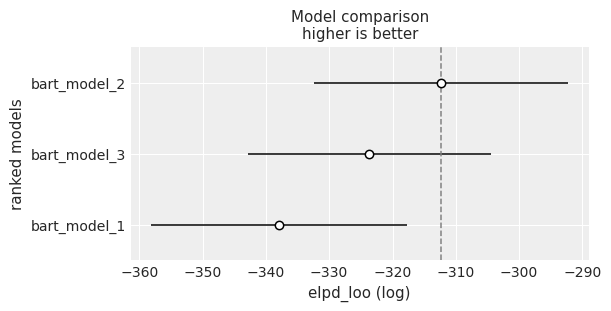

In [402]:
az.plot_compare(comparison)

## Modeling Chlorophyll

In [427]:
X_chl = chl_subset.dropna().filter(regex='Rrc')
Y_chl = chl_subset.dropna().log_chl
Y_hplc_flag = chl_subset.dropna().hplc_flag

<Axes: xlabel='log_chl', ylabel='Density'>

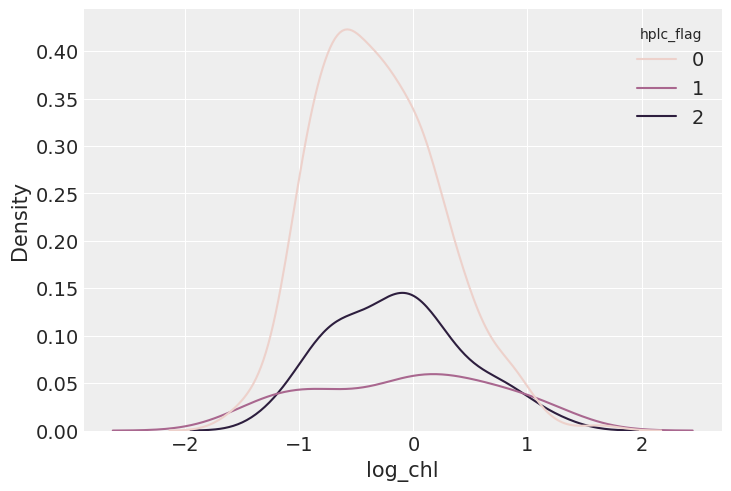

In [430]:
sb.kdeplot(chl_subset.dropna(), x='log_chl', hue='hplc_flag')

/Users/erdemkarakoylu/miniconda3/envs/pymc_base/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


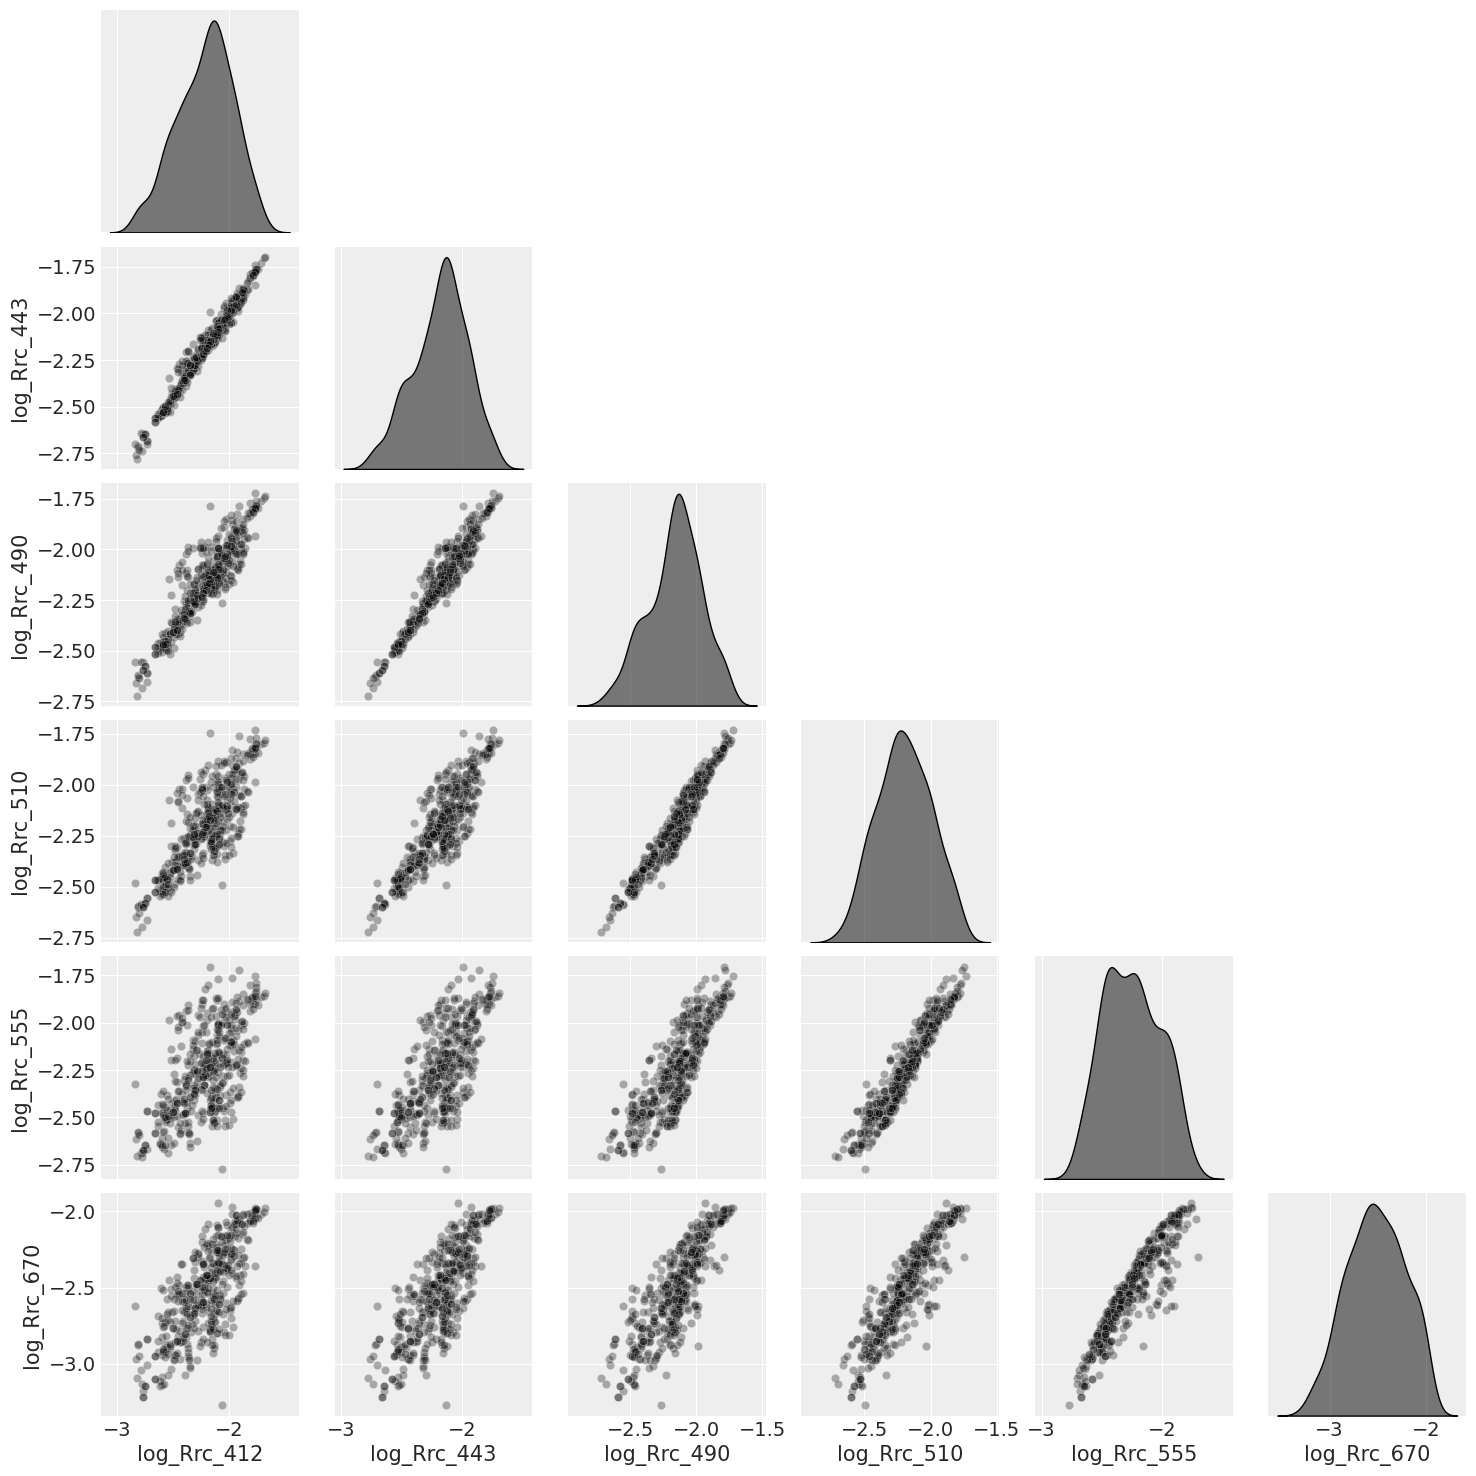

In [431]:
sb.pairplot(chl_subset.dropna().filter(
    like='Rrc', axis=1), corner=True, plot_kws = {'color': 'k', 'alpha': 0.3}, 
    diag_kws={'color': 'k', 'alpha': 0.5}, diag_kind='kde')
f = pp.gcf()

## Model Formulation

In [ ]:
#Y_hplc_flag = 2 is still hplc. It is just used to indicate 

Y_hplc_flag.unique()
Y_hplc_flag.replace(2, 1, inplace=True)

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_98221/2995749021.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Y_hplc_flag.replace(2, 1, inplace=True)


In [434]:
Y_hplc_flag.unique()

array([0, 1], dtype=int8)

In [441]:
chl_type = pd.Categorical(Y_hplc_flag.values, categories=['chl', 'hplc'])

In [443]:
chl_type = Y_hplc_flag.map({0: 'fluo', 1: 'hplc'})

In [ ]:
x_idx, x_names = X_chl.columns.factorize()
chl_type_code, chl_cat = chl_type.factorize()
λ =   [li.split('Rrc_')[-1] for li in x_names]

coords_chl= {
    'obs_idx': X_chl.index,
    'λ_toa': λ, 
    'chl_type_idx': chl_type_code

}

In [440]:
hpc_flag

Index([0, 1], dtype='int8')